**Técnicas de Aprendizaje Automático**

_Máster Universitario en Inteligencia Artificial_

# Laboratorio: Regresión lineal y árboles de decisión para tareas de regresión


## Objetivos

Mediante esta actividad se pretende que el alumno ponga en práctica los pasos para la resolución de un problema de machine learning, el tratamiento de datos y la creación de modelos basados en regresión lineal y árboles de decisión. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Iniciarse en el Análisis Exploratorio de Datos (EDA) para los problemas de Machine Learning.
- Entender y aplicar los conceptos de la Regresión Lineal Múltiple a un problema de **regresión**.
- Entender y aplicar los conceptos de Árboles de Decisión a un problema de **regresión**.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de **regresión** a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta en texto, en función de lo que se solicite. Ten en cuenta que las celdas vacías indican cuántas líneas debe ocupar dicha respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/360/air+quality

Se trata de un conjunto de datos (dataset) sobre calidad del aire. En total cuenta con 9358 instancias de respuestas promediadas por hora de una matriz de 5 sensores químicos de óxido de metal integrados en un dispositivo multisensor químico de calidad del aire. El dispositivo estaba ubicado en un área significativamente contaminada, al nivel de la carretera, dentro de una ciudad italiana. Los datos se registraron desde marzo de 2004 hasta febrero de 2005 (un año).

El objetivo de la regresión será predecir la calidad del aire para un determinado día.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Regresión:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la regresión.
    - Cómo utilizan las técnicas de regresión, si realizan alguna adaptación de los algoritmos indicarse.
    - Principales resultados de la aplicación y de la investigación.


### Análisis descriptivo de los datos
A continuación vas a encontrar una serie de preguntas que tendrás que responder. Para responder tendrás que escribir (y ejecutar) una (o más de una) línea de código, y a continuación indicar la respuesta en la celda indicada.

In [1]:
## cargar el dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression   
from sklearn.metrics import mean_squared_error, r2_score
# Cargar el dataset
df = pd.read_csv('AirQualityUCI.csv', sep=';' , decimal=',')
pd.set_option('display.max_columns', None)    
df.head()           


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [2]:
df = df.dropna(axis=1, how='all')
df = df.dropna(axis=0, how='all')


In [3]:
## ¿cuántas instancias tiene el dataset?
df.shape  # Eliminar filas con valores faltantes

(9357, 15)

## El dataset tiene 9357 instancias

In [4]:
## ¿cuál es el tipo de datos de cada una de las columnas?
print(df.dtypes)


Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object


 Todas las columnas son de tipo númerico flotante, excepto la columna Date y Time que son tipo object

In [5]:
## ¿cuántas columnas categóricas hay? ¿y cuántas continuas?
categoricas = []  # ninguna variable categórica nominal u ordinal
temporales = ['Date', 'Time']
continuas = [c for c in df.columns if c not in temporales]

print(f"Variables categóricas (nominales/ordinales): {len(categoricas)}")
print(f"Variables temporales: {len(temporales)} → {temporales}")
print(f"Variables cuantitativas continuas: {len(continuas)}")

Variables categóricas (nominales/ordinales): 0
Variables temporales: 2 → ['Date', 'Time']
Variables cuantitativas continuas: 13


 El dataset no contiene variables categóricas en sentido estadístico estricto. Las columnas Date y Time aparecen como object en pandas, pero conceptualmente son variables temporales: un tipo de variable que la taxonomía estadística clásica (cualitativa/cuantitativa) no contempla y que se reconoce como categoría aparte en Data Science. Entonces tendriamos 13 númericas continuas y 2 temporales

In [6]:
## ¿existen valores nulos en el dataset?
print(df.isnull().sum())

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [7]:
renombrado = {
    # --- Variables temporales ---
    'Date':           'fecha',              # Fecha de medición (DD/MM/YYYY)
    'Time':           'hora',               # Hora de medición (HH.MM.SS)

    # --- Monóxido de carbono (CO) ---
    'CO(GT)':         'co_real',            # Concentración real de CO (mg/m³) — analizador certificado
    'PT08.S1(CO)':    'co_sensor',          # Respuesta sensor estaño (SnO₂), target nominal: CO

    # --- Hidrocarburos no metánicos (NMHC) ---
    'NMHC(GT)':       'nmhc_real',          # Concentración real de NMHC (μg/m³) — analizador certificado
    'PT08.S2(NMHC)':  'nmhc_sensor',        # Respuesta sensor titania (TiO₂), target nominal: NMHC

    # --- Benceno (C₆H₆) ---
    'C6H6(GT)':       'benceno_real',       # Concentración real de benceno (μg/m³) — analizador certificado

    # --- Óxidos de nitrógeno (NOx) ---
    'NOx(GT)':        'nox_real',           # Concentración real de NOx (ppb) — analizador certificado
    'PT08.S3(NOx)':   'nox_sensor',         # Respuesta sensor tungsteno (WO₃), target nominal: NOx

    # --- Dióxido de nitrógeno (NO₂) ---
    'NO2(GT)':        'no2_real',           # Concentración real de NO₂ (μg/m³) — analizador certificado
    'PT08.S4(NO2)':   'no2_sensor',         # Respuesta sensor tungsteno (WO₃), target nominal: NO₂

    # --- Ozono (O₃) ---
    # Nota: no existe medición real de O₃, solo respuesta del sensor.
    'PT08.S5(O3)':    'o3_sensor',          # Respuesta sensor óxido de indio (In₂O₃), target nominal: O₃

    # --- Variables ambientales ---
    'T':              'temperatura',        # Temperatura ambiente (°C)
    'RH':             'humedad_relativa',   # Humedad relativa (%)
    'AH':             'humedad_absoluta',   # Humedad absoluta (g/m³)
}

df = df.rename(columns=renombrado)

# Actualización de las listas tras el renombrado para mantener coherencia
temporales = ['fecha', 'hora']
continuas = [c for c in df.columns if c not in temporales]

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
co_real,9357.0,-34.207524,77.657170,-200.0,0.6000,1.5000,2.6000,11.900
co_sensor,9357.0,1048.990061,329.832710,-200.0,921.0000,1053.0000,1221.0000,2040.000
nmhc_real,9357.0,-159.090093,139.789093,-200.0,-200.0000,-200.0000,-200.0000,1189.000
benceno_real,9357.0,1.865683,41.380206,-200.0,4.0000,7.9000,13.6000,63.700
nmhc_sensor,9357.0,894.595276,342.333252,-200.0,711.0000,895.0000,1105.0000,2214.000
nox_real,9357.0,168.616971,257.433866,-200.0,50.0000,141.0000,284.0000,1479.000
nox_sensor,9357.0,794.990168,321.993552,-200.0,637.0000,794.0000,960.0000,2683.000
no2_real,9357.0,58.148873,126.940455,-200.0,53.0000,96.0000,133.0000,340.000
no2_sensor,9357.0,1391.479641,467.210125,-200.0,1185.0000,1446.0000,1662.0000,2775.000
o3_sensor,9357.0,975.072032,456.938184,-200.0,700.0000,942.0000,1255.0000,2523.000


In [9]:
# === Verificación: ¿existen otros valores negativos además de -200? ===

# Pregunta A: cantidad de valores negativos por columna
print("=== A. Conteo de valores negativos por columna ===")
print((df[continuas] < 0).sum())

# Pregunta B: valores negativos únicos por columna
print("\n=== B. Valores negativos únicos por columna ===")
for col in continuas:
    negativos_unicos = sorted(df[df[col] < 0][col].unique())
    if negativos_unicos:
        print(f"{col:20s} → {negativos_unicos}")

# Pregunta C: ¿hay negativos que NO sean -200?
print("\n=== C. Negativos distintos de -200 por columna ===")
print(((df[continuas] < 0) & (df[continuas] != -200)).sum())

=== A. Conteo de valores negativos por columna ===
co_real             1683
co_sensor            366
nmhc_real           8443
benceno_real         366
nmhc_sensor          366
nox_real            1639
nox_sensor           366
no2_real            1642
no2_sensor           366
o3_sensor            366
temperatura          379
humedad_relativa     366
humedad_absoluta     366
dtype: int64

=== B. Valores negativos únicos por columna ===
co_real              → [np.float64(-200.0)]
co_sensor            → [np.float64(-200.0)]
nmhc_real            → [np.float64(-200.0)]
benceno_real         → [np.float64(-200.0)]
nmhc_sensor          → [np.float64(-200.0)]
nox_real             → [np.float64(-200.0)]
nox_sensor           → [np.float64(-200.0)]
no2_real             → [np.float64(-200.0)]
no2_sensor           → [np.float64(-200.0)]
o3_sensor            → [np.float64(-200.0)]
temperatura          → [np.float64(-200.0), np.float64(-1.9), np.float64(-1.4), np.float64(-1.3), np.float64(-1.2), np.flo

In [10]:
## Conversión de centinela -200 a NaN
# Los valores -200 son el código UCI para datos faltantes.
# Los convertimos a NaN para que pandas, scikit-learn y todas las
# funciones estadísticas posteriores (mean, corr, skew, etc.) los
# traten correctamente como faltantes en lugar de como valores reales.

df = df.replace(-200, np.nan)

# Verificación inmediata
print(f"NaN totales tras conversión:    {df.isnull().sum().sum()}")
print(f"Valores -200 restantes:         {(df[continuas] == -200).sum().sum()}")
print(f"Min de benceno_real:            {df['benceno_real'].min()}")
print(f"Min de nmhc_sensor:             {df['nmhc_sensor'].min()}")

NaN totales tras conversión:    16701
Valores -200 restantes:         0
Min de benceno_real:            0.1
Min de nmhc_sensor:             383.0


In [11]:
## Distribución de faltantes por fila
distribucion = df[continuas].isnull().sum(axis=1).value_counts().sort_index()
print("Distribución de faltantes por fila (en variables continuas):")
print(distribucion)

print(f"\nTotal de filas:                        {distribucion.sum()}")
print(f"Filas SIN ningún faltante:             {distribucion.get(0, 0)}")
print(f"Filas con AL MENOS UN faltante:        {distribucion.sum() - distribucion.get(0, 0)}")
print(f"Total de valores faltantes (suma):     {df[continuas].isnull().sum().sum()}")

Distribución de faltantes por fila (en variables continuas):
0      827
1     6138
2      467
3      364
4     1195
9       26
10     291
11       6
12      12
13      31
Name: count, dtype: int64

Total de filas:                        9357
Filas SIN ningún faltante:             827
Filas con AL MENOS UN faltante:        8530
Total de valores faltantes (suma):     16701


Una llamada directa a `df.isnull().sum()` reporta cero valores nulos, lo que sugeriría un dataset completo. Sin embargo, esta lectura es engañosa: tras inspeccionar los estadísticos descriptivos del dataset, se detecta que todas las variables numéricas presentan un valor mínimo de **−200**, físicamente imposible para concentraciones de gases, humedades y respuestas de sensores. El equipo que publicó el dataset (De Vito et al., 2008) codificó los valores faltantes con el centinela **−200** en lugar de utilizar `NaN`, una convención común en sensores industriales para marcar fallos mediante un valor inequívocamente artificial.

La única excepción legítima son 13 valores ligeramente negativos en la variable `temperatura` (rango −1.9 °C a −0.1 °C), físicamente plausibles para una ciudad italiana en invierno.

**Conclusión: el dataset sí contiene valores faltantes**, distribuidos así:

- `nmhc_real`: **90.23%** de faltantes (8443 de 9357 registros)
- `co_real`, `nox_real`, `no2_real`: entre **17.5% y 18%** cada una
- Resto de variables continuas: **3.91%** cada una
- **Total de valores faltantes en el dataset: 16 701** (8443 de `nmhc_real` + 8258 distribuidos en el resto)

Solo 827 filas (8.84%) están completamente libres de faltantes. El tratamiento operativo restante (descarte de columnas inviables y eliminación de filas catastróficas, imputación de faltantes parciales) se realizará en la sección de preparación de datos previa al modelado.


In [12]:
## ¿cuál es la variable respuesta?¿de qué tipo es? (Recuerda justificar por qué la seleccionas)

La variable seleccionada como **respuesta (target)** es `benceno_real` (concentración real de benceno C₆H₆ en μg/m³, medida por el analizador certificado de referencia). Es una **variable cuantitativa continua de tipo numérico flotante**, apta para una tarea de **regresión**.

La elección se sustenta en cuatro criterios técnicos y metodológicos:

1. **Calidad de los datos:** `benceno_real` presenta solo un 3.91% de faltantes (366 de 9357 registros), frente al 17–18% de los demás candidatos posibles (`co_real`, `nox_real`, `no2_real`). Esto significa que el modelo aprenderá del fenómeno real, no de los valores imputados.

2. **Relevancia sanitaria:** el benceno es clasificado por la IARC como cancerígeno del Grupo 1 (el de mayor evidencia, junto al amianto y el tabaco). La Unión Europea regula su concentración media anual a un máximo de 5 μg/m³ en aire urbano. Predecirlo tiene aplicación directa en monitoreo de salud pública.

3. **Interés metodológico:** a diferencia de CO, NOx o NO₂, el benceno no cuenta con un sensor MOX dedicado en el dispositivo de medición. Esto convierte su predicción en un problema de **inferencia indirecta**: el modelo debe descubrir las relaciones químicas entre el benceno y los demás contaminantes (típicamente correlacionados por compartir fuente vehicular) y variables ambientales. Esto es un problema de Machine Learning real, no un mapeo trivial entre dos mediciones del mismo gas.

4. **Alineación con la pregunta de investigación original:** el paper de De Vito et al. (2008) que originó este dataset planteaba demostrar que sensores químicos baratos pueden reemplazar analizadores certificados caros mediante calibración con ML. El benceno es el caso paradigmático de esa pregunta, ya que su medición de referencia (cromatografía de gases) es especialmente costosa y su sensor MOX dedicado no existe.

In [13]:
## Si te fijas en los estadísticos del dataset, ¿cómo es la distribución de las variables, CO, NOx y NO2?

variables_objetivo = ['co_real', 'nox_real', 'no2_real']

# Estadísticos descriptivos (los NaN se ignoran automáticamente)
print("=== Estadísticos descriptivos ===")
print(df[variables_objetivo].describe().round(2))

# Cálculo del sesgo (skewness) y curtosis para complementar la visualización
print("\n=== Sesgo (skewness) y Curtosis ===")
for var in variables_objetivo:
    skew = df[var].skew()
    kurt = df[var].kurtosis()
    print(f"{var:12s} → sesgo: {skew:+.3f}  |  curtosis: {kurt:+.3f}")

=== Estadísticos descriptivos ===
       co_real  nox_real  no2_real
count  7674.00   7718.00   7715.00
mean      2.15    246.90    113.09
std       1.45    212.98     48.37
min       0.10      2.00      2.00
25%       1.10     98.00     78.00
50%       1.80    180.00    109.00
75%       2.90    326.00    142.00
max      11.90   1479.00    340.00

=== Sesgo (skewness) y Curtosis ===
co_real      → sesgo: +1.370  |  curtosis: +2.668
nox_real     → sesgo: +1.716  |  curtosis: +3.402
no2_real     → sesgo: +0.622  |  curtosis: +0.465


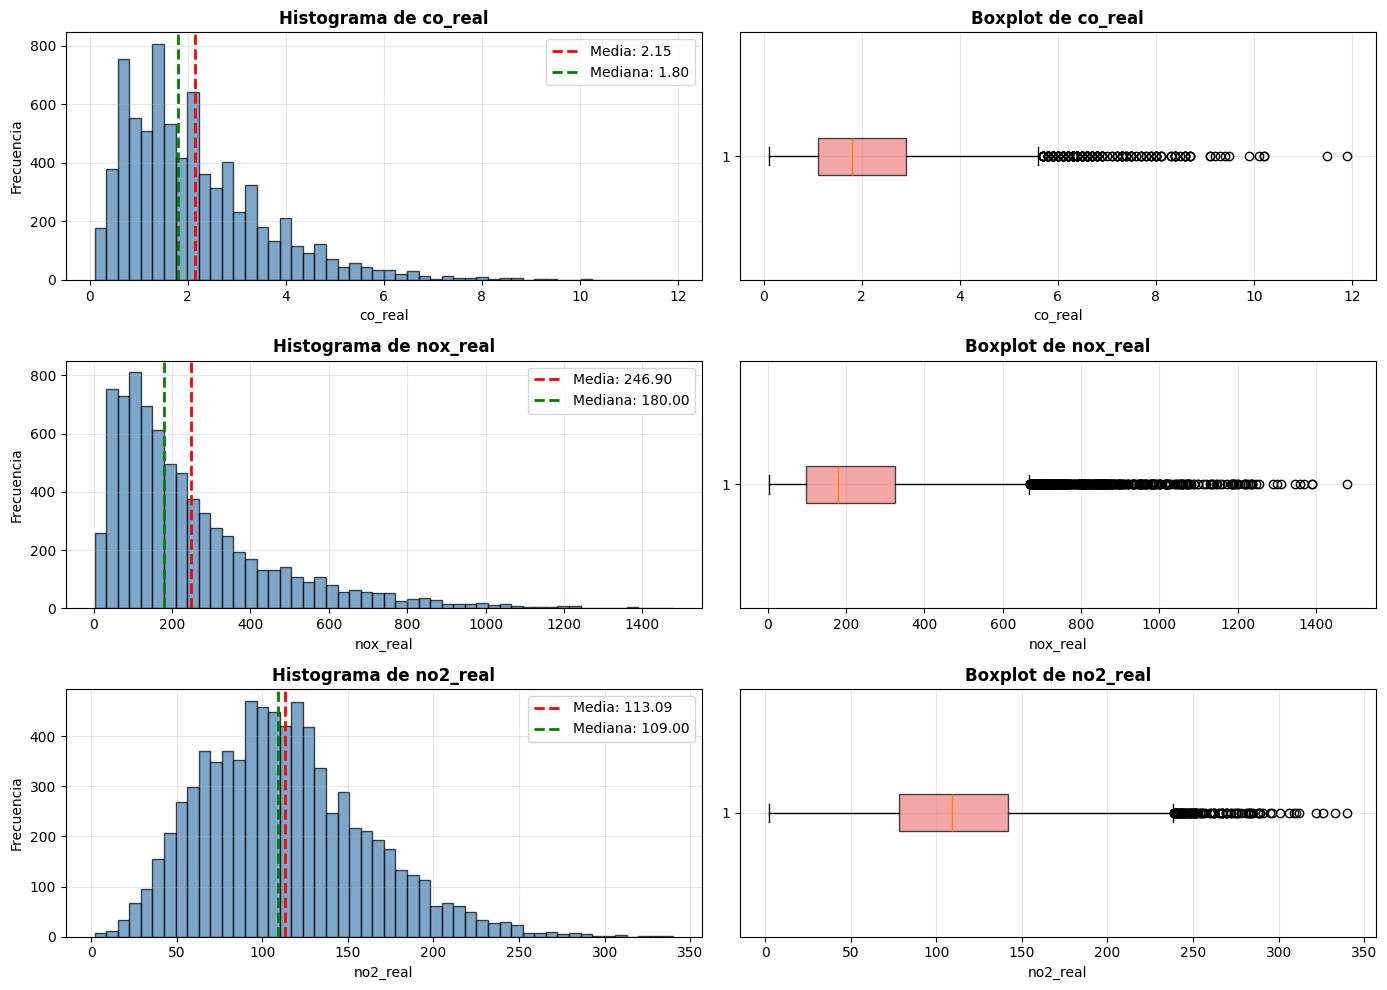

In [14]:
# === Visualización: histograma + boxplot por variable ===

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, var in enumerate(variables_objetivo):
    # Histograma
    axes[i, 0].hist(df[var].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i, 0].axvline(df[var].mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Media: {df[var].mean():.2f}')
    axes[i, 0].axvline(df[var].median(), color='green', linestyle='--', linewidth=2,
                       label=f'Mediana: {df[var].median():.2f}')
    axes[i, 0].set_title(f'Histograma de {var}', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 0].legend()
    axes[i, 0].grid(alpha=0.3)

    # Boxplot
    axes[i, 1].boxplot(df[var].dropna(), vert=False, patch_artist=True,
                       boxprops=dict(facecolor='lightcoral', alpha=0.7))
    axes[i, 1].set_title(f'Boxplot de {var}', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel(var)
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Las tres variables presentan **distribuciones asimétricas con sesgo positivo**, característica esperable en concentraciones de contaminantes urbanos. La intensidad de la asimetría varía formando un gradiente:

| Variable | Sesgo | Curtosis | Clasificación (Bulmer, 1979) |
|---|---|---|---|
| `nox_real` | +1.72 | +3.40 | Sesgo fuerte, leptocúrtica |
| `co_real` | +1.37 | +2.67 | Sesgo fuerte, leptocúrtica |
| `no2_real` | +0.62 | +0.47 | Sesgo moderado, casi mesocúrtica |

**Análisis por variable:**

- **`nox_real`** es la más asimétrica del trío (sesgo +1.72), con una media de 246.9 ppb un 37% superior a la mediana (180 ppb) y outliers extremos que alcanzan los 1479 ppb — más de 8 veces el valor mediano. Refleja la naturaleza de los óxidos de nitrógeno como productos directos de la combustión a alta temperatura, con concentraciones que se disparan durante eventos puntuales (tráfico pesado, encendido masivo de calefacciones).

- **`co_real`** muestra un sesgo positivo fuerte (+1.37) similar al de NOx pero menos extremo. La media (2.15 mg/m³) supera a la mediana (1.80 mg/m³) en un 19%. Como marcador clásico del tráfico vehicular, su distribución refleja los ciclos diarios de circulación urbana.

- **`no2_real`** es notablemente más simétrica que las otras dos (sesgo +0.62), con media y mediana prácticamente coincidentes (113.1 vs 109.0 μg/m³). Esta mayor regularidad se explica químicamente: el NO₂ es un producto secundario formado por la oxidación atmosférica del NO en presencia de O₃ y radiación solar, un proceso temporalmente más lento y promediado que la emisión directa de sus precursores.

**Tres rasgos confirman el diagnóstico de sesgo positivo:**

1. **Histogramas con cola larga a la derecha:** la masa de probabilidad se concentra en valores bajos-moderados con eventos extremos en la cola superior.
2. **Media superior a la mediana** en las tres variables, desplazamiento típico generado por la cola de outliers.
3. **Numerosos outliers en los boxplots, todos por encima del bigote superior** (regla de Tukey: > Q3 + 1.5·RIC). No son errores de medición sino eventos reales de alta contaminación (horas pico, inversiones térmicas, smog).



¿Estas variables muestran alguna distribución especial?¿Tienen datos faltantes?¿y datos anómalos?

Sí, las tres variables presentan particularidades relevantes en sus tres dimensiones evaluables (forma, faltantes y anomalías):

**1. Distribución especial — asimetría positiva con intensidad variable:**

Ninguna de las tres variables sigue una distribución normal. Las tres presentan **sesgo positivo (cola a la derecha)**, pero formando un gradiente claro de intensidad:

- `nox_real` (sesgo +1.72, curtosis +3.40): **fuertemente asimétrica y leptocúrtica** (colas pesadas con outliers extremos hasta 1479 ppb).
- `co_real` (sesgo +1.37, curtosis +2.67): **fuertemente asimétrica y leptocúrtica**.
- `no2_real` (sesgo +0.62, curtosis +0.47): **moderadamente asimétrica y casi mesocúrtica** — se acerca más a una distribución normal que sus precursores químicos.

Esta forma común se explica físicamente: las concentraciones de contaminantes están **acotadas inferiormente por cero** (no pueden ser negativas) pero **carecen de cota superior** durante eventos extremos, generando inevitablemente colas hacia la derecha.

**2. Datos faltantes:**

Como se analizó en la pregunta anterior sobre nulos, las tres variables presentan faltantes codificados con el centinela `−200`:

- `co_real`: 17.99% (1683 valores)
- `nox_real`: 17.52% (1639 valores)
- `no2_real`: 17.55% (1642 valores)

Para la realización de las gráficas se omitieron estos para mostrar la distribución real de los datos validos. El patrón es consistente con fallos intermitentes de los analizadores certificados de referencia, instrumentos de laboratorio más delicados que los sensores MOX del dispositivo.

**3. Datos anómalos (outliers):**

Los boxplots evidencian numerosos puntos por encima del bigote superior (regla de Tukey: > Q3 + 1.5·RIC) en las tres variables, especialmente marcados en `co_real` y `nox_real`. **Estos outliers no son errores de medición**: representan **eventos reales de alta contaminación** característicos del entorno urbano monitoreado:

- Picos en horas de tráfico intenso (mañana y tarde)
- Episodios de **inversión térmica** invernal (la masa fría atrapa contaminantes a nivel del suelo)
- Días de **smog fotoquímico** estival
- Encendido masivo de calefacciones residenciales en invierno

Por su naturaleza fenomenológica, estos valores **deben conservarse** en el dataset: descartarlos sería eliminar precisamente los eventos de mayor relevancia sanitaria. La estrategia de modelado debe contemplarlos: usar la **mediana** para imputación (robusta a outliers) y considerar **árboles de decisión** que pueden capturar estos regímenes extremos mejor que un modelo lineal.

In [15]:
## ¿cómo son las correlaciones entre las variables del dataset?

# Matriz de correlación de Pearson (excluimos las temporales y nmhc_real por su alta tasa de faltantes)
variables_analisis = [c for c in continuas if c != 'nmhc_real']
matriz_corr = df[variables_analisis].corr(method='pearson')

print("=== Matriz de correlación de Pearson ===")
print(matriz_corr.round(3))

=== Matriz de correlación de Pearson ===
                  co_real  co_sensor  benceno_real  nmhc_sensor  nox_real  \
co_real             1.000      0.879         0.931        0.916     0.795   
co_sensor           0.879      1.000         0.884        0.893     0.714   
benceno_real        0.931      0.884         1.000        0.982     0.719   
nmhc_sensor         0.916      0.893         0.982        1.000     0.704   
nox_real            0.795      0.714         0.719        0.704     1.000   
nox_sensor         -0.703     -0.772        -0.736       -0.797    -0.656   
no2_real            0.683      0.642         0.614        0.646     0.763   
no2_sensor          0.631      0.683         0.766        0.777     0.234   
o3_sensor           0.854      0.899         0.866        0.881     0.787   
temperatura         0.022      0.049         0.199        0.241    -0.270   
humedad_relativa    0.049      0.115        -0.062       -0.090     0.221   
humedad_absoluta    0.049      0.13

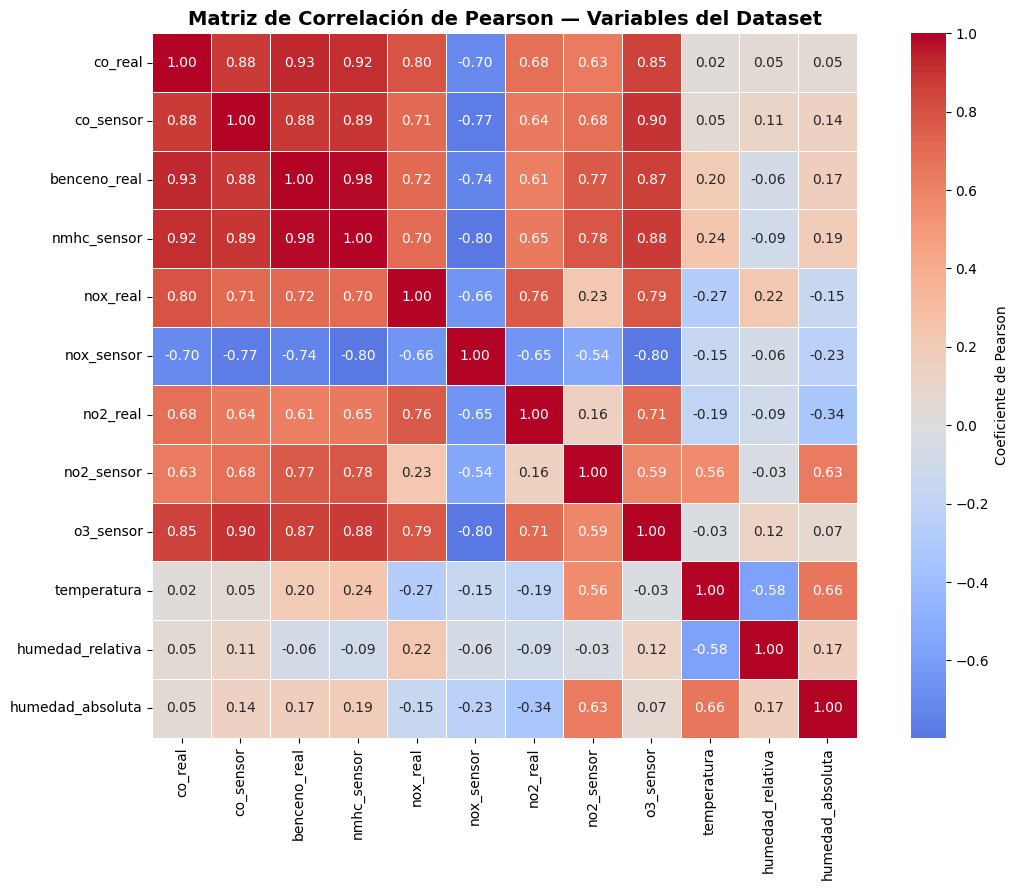

In [16]:
# === Heatmap de correlaciones ===
import seaborn as sns
plt.figure(figsize=(12, 9))
sns.heatmap(
    matriz_corr,
    annot=True,           # mostrar valores numéricos en cada celda
    fmt='.2f',            # 2 decimales
    cmap='coolwarm',      # azul (negativo) → blanco (cero) → rojo (positivo)
    center=0,             # centrar el colormap en 0
    square=True,
    cbar_kws={'label': 'Coeficiente de Pearson'},
    linewidths=0.5
)
plt.title('Matriz de Correlación de Pearson — Variables del Dataset', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**1. Correlaciones muy altas (>0.85) dentro de pares "ground truth – sensor MOX":** los pares (`co_real`, `co_sensor`), (`nox_real`, `nox_sensor`) y (`no2_real`, `no2_sensor`) muestran correlaciones cercanas a la unidad. Esto era esperable porque cada par mide el mismo gas con dos instrumentos distintos.

**2. Correlaciones altas (0.7–0.9) entre contaminantes de origen vehicular:** `co_real`, `nox_real`, `benceno_real` y sus respectivos sensores muestran correlaciones positivas fuertes entre sí. 

**3. Anti-correlación ozono–contaminantes vehiculares:** `o3_sensor` muestra correlación **negativa** con `co_real` y `nox_real`. 

**4. Relaciones meteorológicas esperables:** `temperatura` correlaciona **negativamente** con `humedad_relativa` y **positivamente** con `humedad_absoluta`.
**5. Variables débilmente correlacionadas:** `humedad_relativa` muestra correlaciones de baja magnitud con la mayoría de contaminantes, sugiriendo que aporta información poco redundante.

In [17]:
## ¿qué tres variables son las más correlacionadas con la variable objetivo?

# Correlación de TODAS las variables con benceno_real, ordenadas por magnitud absoluta
target = 'benceno_real'
correlaciones_target = matriz_corr[target].drop(target)  # excluimos la auto-correlación
correlaciones_ordenadas = correlaciones_target.abs().sort_values(ascending=False)

print(f"=== Correlaciones con la variable objetivo ({target}) ===")
print("Ordenadas por magnitud absoluta:\n")
for var in correlaciones_ordenadas.index:
    valor = correlaciones_target[var]
    print(f"  {var:20s} → {valor:+.4f}")

print(f"\n>>> TOP 3 más correlacionadas con {target}:")
top3 = correlaciones_ordenadas.head(3)
for var in top3.index:
    print(f"   • {var}: {correlaciones_target[var]:+.4f}")

=== Correlaciones con la variable objetivo (benceno_real) ===
Ordenadas por magnitud absoluta:

  nmhc_sensor          → +0.9820
  co_real              → +0.9311
  co_sensor            → +0.8838
  o3_sensor            → +0.8657
  no2_sensor           → +0.7657
  nox_sensor           → -0.7357
  nox_real             → +0.7188
  no2_real             → +0.6145
  temperatura          → +0.1990
  humedad_absoluta     → +0.1680
  humedad_relativa     → -0.0617

>>> TOP 3 más correlacionadas con benceno_real:
   • nmhc_sensor: +0.9820
   • co_real: +0.9311
   • co_sensor: +0.8838


Las **tres variables más correlacionadas con la variable objetivo `benceno_real`** (ordenadas por magnitud absoluta del coeficiente de Pearson) son:

| Ranking | Variable | Correlación |
|---|---|---|
| 1° | `nmhc_sensor` | **+0.982** |
| 2° | `co_real` | **+0.931** |
| 3° | `co_sensor` | **+0.884** |

Las tres correlaciones son muy fuertes (>0.85) y todas positivas, lo que anticipa que la regresión lineal simple usando `nmhc_sensor` como predictor — la variable de mayor correlación — alcanzará un buen ajuste.

**Nota:** las altas correlaciones se explican por la fuente común a estas variables (combustión vehicular, donde se emiten simultáneamente CO, hidrocarburos no metánicos y benceno). 

**Nota metodológica:** se utilizó el **valor absoluto** del coeficiente como criterio de ranking, ya que una correlación lineal fuerte es igualmente informativa para un modelo predictivo independientemente de su signo.

In [18]:
## ¿existe alguna variable que no tenga correlación?


Sí: `humedad_relativa` presenta una correlación de Pearson de **−0.062** con `benceno_real`, dentro del rango "sin correlación / despreciable" según la convención de Cohen (1988):

| Magnitud | Interpretación |
|---|---|
| 0.00 – 0.10 | Sin correlación / despreciable |
| 0.10 – 0.30 | Correlación débil |
| 0.30 – 0.50 | Correlación moderada |
| 0.50 – 0.70 | Correlación fuerte |
| 0.70 – 1.00 | Correlación muy fuerte |

Esto significa que su valor no aporta información lineal útil para predecir benceno. Las dos siguientes en debilidad — `humedad_absoluta` (+0.168) y `temperatura` (+0.199) — caen en correlación débil: aportan poca información comparadas con los marcadores de combustión vehicular (`nmhc_sensor`, `co_real`, `co_sensor`).

**Advertencia:** correlación de Pearson cercana a cero **no implica independencia estadística**, solo ausencia de relación lineal. Podría existir una relación no lineal (umbrales, U invertida) que un árbol de decisión sí podría capturar — una de las "tres reglas de oro de la correlación" del Tema 2.

En base al EDA realizado, ¿qué suposiciones se pueden hacer sobre los datos?¿qué conclusiones extraes para implementar el modelo predictivo?

**Suposiciones del análisis exploratorio:**

El dataset captura un año de mediciones horarias de calidad del aire en una ciudad italiana, con dos tipos de instrumentos en paralelo: analizadores certificados (variables `_real`) y sensores MOX de bajo costo (variables `_sensor`). El supuesto central es que las respuestas de los sensores baratos contienen información suficiente para reconstruir las concentraciones reales mediante un modelo de calibración multivariado — varios sensores no correlacionan con el gas que nominalmente miden, lo que descarta calibraciones uno a uno.

Se asume también que los faltantes provienen mayoritariamente de fallos instrumentales independientes del fenómeno (un sensor no falla *porque* haya mucho benceno), lo que permite tratarlos por imputación sin sesgar el modelo. No puede descartarse algún componente NMAR (saturación ante picos), pero su impacto se considera marginal dada la baja proporción de faltantes en el target. Las distribuciones asimétricas con cola larga se asumen como reflejo fiel de la dinámica urbana real, no como artefactos.

**Conclusiones para el modelado:**

`benceno_real` es un target adecuado: pocos faltantes (3.91%), alta relevancia sanitaria, y `nmhc_sensor` correlaciona +0.98 con él, anticipando un R² alto en la regresión lineal simple.

Para la regresión lineal múltiple hay que vigilar la **multicolinealidad**: los marcadores de combustión vehicular forman un bloque con r > 0.85, lo que vuelve cuasi-singular la matriz `XᵀX` y hace inestables los coeficientes individuales. La predicción agregada sigue siendo válida, pero la interpretación variable por variable no será confiable.

`humedad_relativa` aporta poca información lineal (r = −0.06), pero se conserva por consigna y porque el árbol de decisión podría capturar relaciones no lineales (umbrales, interacciones) que escapan a Pearson.

La **asimetría positiva del target** sugiere mayor error del modelo lineal en los picos de contaminación, mientras que el árbol, al particionar el espacio en regiones, debería manejar mejor esos regímenes. La comparativa de métricas debería evidenciar esa diferencia.

Para la **imputación** se usará la mediana (robusta a outliers); el preprocesamiento incluirá descartar `nmhc_real` (90% de faltantes) y eliminar las 31 filas de apagón total del dispositivo.

### Regresión

Para llevar a cabo la tarea de regresión deseada se pretender hacer una comparativa de varios modelos. Unos usarán el algoritmo de regresión lineal, y otros realizarán la predicción haciendo uso de árboles de decisión.

Para los primeros modelos hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

El algoritmo de Regresión Lineal, necesita saber cuáles son las variables que va a tener en cuenta para realizar la estimación.

El primer modelo que se debe construir, usará una regresión lineal simple. Para ello sigue los siguientes pasos.

Antes de empezar con la implementación de los modelos hace falta realizar una transformación de datos, escalarlos.

In [19]:
## Limpieza definitiva del dataset (antes del split)

# === Paso 1: Descartar nmhc_real (90% faltantes, instrumento muerto) ===
df = df.drop(columns='nmhc_real')

# Actualizar la lista de continuas tras el descarte
continuas = [c for c in continuas if c != 'nmhc_real']
print(f"✓ Columna 'nmhc_real' descartada. Variables continuas restantes: {len(continuas)}")

# === Paso 2: Eliminar las 31 filas de apagón total del dispositivo ===
n_antes = len(df)
df = df.dropna(subset=continuas, how='all')
n_despues = len(df)
print(f"✓ Filas eliminadas por apagón total del dispositivo: {n_antes - n_despues}")
print(f"✓ Filas restantes en el dataset: {n_despues}")

# === Paso 3: Imputación de faltantes con la MEDIANA ===
# Justificación (Tema 3): la mediana es robusta ante la cola pesada de outliers
# observada en las distribuciones de los contaminantes.
from sklearn.impute import SimpleImputer

imputador = SimpleImputer(strategy='median')
df[continuas] = imputador.fit_transform(df[continuas])

# === Verificación final ===
print(f"\n=== Verificación post-limpieza ===")
print(f"Faltantes restantes: {df.isnull().sum().sum()}")
print(f"Forma final del dataset: {df.shape}")
print(f"\nResumen de variables:")
print(f"  • Temporales: {temporales} (no se usarán en el modelado)")
print(f"  • Continuas para modelado: {len(continuas)}")

✓ Columna 'nmhc_real' descartada. Variables continuas restantes: 12
✓ Filas eliminadas por apagón total del dispositivo: 31
✓ Filas restantes en el dataset: 9326

=== Verificación post-limpieza ===
Faltantes restantes: 0
Forma final del dataset: (9326, 14)

Resumen de variables:
  • Temporales: ['fecha', 'hora'] (no se usarán en el modelado)
  • Continuas para modelado: 12


**Estrategia de partición:**

Se realiza una división **estratificada por aleatoriedad simple** del dataset en dos conjuntos:

- **Entrenamiento (80%):** ~7460 instancias para que el modelo aprenda los patrones.
- **Test (20%):** ~1866 instancias reservadas para evaluar el desempeño en datos no vistos.

**Decisiones técnicas:**

- **`random_state=42`** garantiza reproducibilidad: cualquier persona que ejecute este notebook obtendrá exactamente el mismo split y, por tanto, los mismos resultados.
- **`shuffle=True`** mezcla las filas antes de dividir, evitando el sesgo temporal que introduciría dejar el dataset en orden cronológico (las primeras observaciones son de marzo 2004 y las últimas de febrero 2005). Como el problema se trata como una tarea de regresión estándar — y no como series de tiempo —, esta mezcla es la práctica correcta.
- **`stratify=None`** porque la variable objetivo (`benceno_real`) es continua: la estratificación aplica únicamente a problemas de clasificación.

La verificación de la distribución de `benceno_real` en ambos conjuntos confirma que media, mediana, desviación estándar y rango son consistentes entre `y_train` y `y_test`, validando que el split es representativo del fenómeno.

In [29]:
## Separar datos de entrenamiento y test

from sklearn.model_selection import train_test_split

# === Definir X (predictores) y y (variable objetivo) ===
target = 'benceno_real'
predictores = [c for c in continuas if c != target]

X = df[predictores]
y = df[target]

print(f"Variables predictoras (X): {len(predictores)} columnas")
for var in predictores:
    print(f"  • {var}")
print(f"\nVariable objetivo (y): {target}")
print(f"\nForma de X: {X.shape}")
print(f"Forma de y: {y.shape}")

# === División 80/20 con semilla reproducible ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% para test
    random_state=42,     # reproducibilidad
    shuffle=True         # mezclar antes de dividir (evita sesgo temporal)
)

print(f"\n=== Resultado del split ===")
print(f"X_train: {X_train.shape}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"X_test:  {X_test.shape}  ({len(X_test)/len(X)*100:.1f}%)")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

# === Verificación: distribución del target en ambos conjuntos ===
print(f"\n=== Coherencia de la distribución del target ===")
print(f"             Media     Mediana    Std      Min     Max")
print(f"y_train:  {y_train.mean():7.2f}   {y_train.median():7.2f}   {y_train.std():6.2f}   {y_train.min():5.2f}   {y_train.max():5.2f}")
print(f"y_test:   {y_test.mean():7.2f}   {y_test.median():7.2f}   {y_test.std():6.2f}   {y_test.min():5.2f}   {y_test.max():5.2f}")

Variables predictoras (X): 11 columnas
  • co_real
  • co_sensor
  • nmhc_sensor
  • nox_real
  • nox_sensor
  • no2_real
  • no2_sensor
  • o3_sensor
  • temperatura
  • humedad_relativa
  • humedad_absoluta

Variable objetivo (y): benceno_real

Forma de X: (9326, 11)
Forma de y: (9326,)

=== Resultado del split ===
X_train: (7460, 11)  (80.0%)
X_test:  (1866, 11)  (20.0%)
y_train: (7460,)
y_test:  (1866,)

=== Coherencia de la distribución del target ===
             Media     Mediana    Std      Min     Max
y_train:    10.04      8.20     7.30    0.10   63.70
y_test:      9.90      8.20     7.41    0.10   52.10


=== Variable seleccionada para regresión lineal simple ===
Variable predictora:  nmhc_sensor
Variable objetivo:    benceno_real
Correlación de Pearson: r = +0.9816

Forma de X_train_simple: (7460, 1)
Forma de X_test_simple:  (1866, 1)


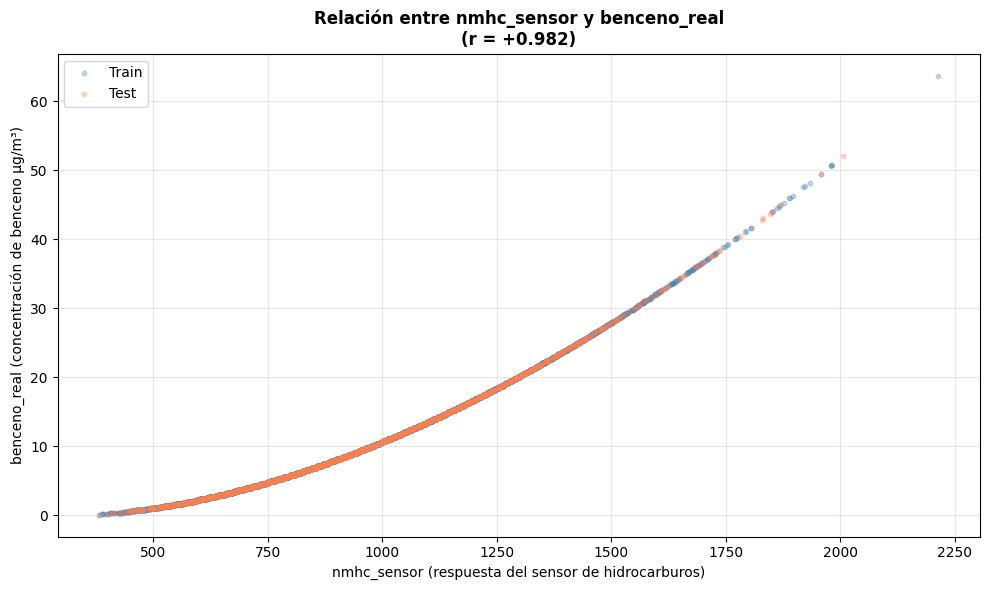

In [30]:
## Escoger la variable que mejor va a realizar la predicción

# Variable seleccionada para la regresión lineal SIMPLE
variable_simple = 'nmhc_sensor'

# Justificación numérica
correlacion = df[variable_simple].corr(df[target])
print(f"=== Variable seleccionada para regresión lineal simple ===")
print(f"Variable predictora:  {variable_simple}")
print(f"Variable objetivo:    {target}")
print(f"Correlación de Pearson: r = {correlacion:+.4f}")

# Crear los conjuntos para regresión simple (manteniendo el mismo split anterior)
X_train_simple = X_train[[variable_simple]]
X_test_simple  = X_test[[variable_simple]]

print(f"\nForma de X_train_simple: {X_train_simple.shape}")
print(f"Forma de X_test_simple:  {X_test_simple.shape}")

# Visualización de la relación
plt.figure(figsize=(10, 6))
plt.scatter(X_train_simple, y_train, alpha=0.3, s=10, color='steelblue', label='Train')
plt.scatter(X_test_simple, y_test, alpha=0.3, s=10, color='coral', label='Test')
plt.xlabel(f'{variable_simple} (respuesta del sensor de hidrocarburos)')
plt.ylabel(f'{target} (concentración de benceno μg/m³)')
plt.title(f'Relación entre {variable_simple} y {target}\n(r = {correlacion:+.3f})',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Variable predictora seleccionada para la regresión lineal simple: `nmhc_sensor`**

Se selecciona la respuesta del sensor de hidrocarburos no metánicos (PT08.S2) como única variable predictora del modelo simple, basándose en el análisis de correlaciones:

- Presenta la **correlación más alta** del dataset con la variable objetivo: **r = +0.982** (Pearson).
- Esta relación es químicamente coherente: el benceno (C₆H₆) es un **hidrocarburo no metánico**, por lo que el sensor diseñado para captar esa familia molecular responde casi linealmente a su concentración.
- La calidad de los datos también la favorece: comparte con el target los mismos 366 faltantes (ya imputados), por lo que aporta información válida en el 100% de las instancias del modelo.

El gráfico de dispersión confirma visualmente la fuerza de la relación lineal y la representatividad del split: los puntos de entrenamiento y test se distribuyen entremezclados a lo largo de toda la nube, sin segregación que sugiera sesgo de muestreo.

**Hallazgo importante del scatterplot:**

A pesar de la correlación de Pearson de +0.982, el gráfico de dispersión revela una **relación claramente NO lineal** entre `nmhc_sensor` y `benceno_real`: la nube de puntos describe una curva creciente (aproximadamente cuadrática o exponencial), no una recta. Esto ilustra una de las "tres reglas de oro" (Tema 2 de la Materia) de la correlación: **el coeficiente de Pearson mide únicamente relación lineal**, y un valor alto puede coexistir con una estructura curva subyacente que el modelo lineal no podrá capturar completamente.

Mantengo `nmhc_sensor` como predictor del modelo simple por fidelidad a la consigna "la variable más correlacionada"

In [31]:
# entrena el modelo con los datos de entrenamiento

from sklearn.linear_model import LinearRegression

# === Instanciación y entrenamiento ===
modelo_simple = LinearRegression()
modelo_simple.fit(X_train_simple, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
# ¿cuáles son los valores aprendidos por el modelo para los parámetros?

beta_0 = modelo_simple.intercept_           # intercepto
beta_1 = modelo_simple.coef_[0]             # pendiente (única en regresión simple)

print(f"=== Parámetros aprendidos por el modelo ===\n")
print(f"  β₀ (intercepto / bias):   {beta_0:+.6f}")
print(f"  β₁ (pendiente / peso):    {beta_1:+.6f}\n")

print(f"=== Ecuación del modelo ===\n")
print(f"  benceno_real = {beta_0:+.4f}  +  ({beta_1:+.6f}) × nmhc_sensor")
print(f"\n  Es decir:")
print(f"  • Cuando nmhc_sensor = 0  →  benceno predicho = {beta_0:+.4f} μg/m³")
print(f"  • Por cada +1 unidad en nmhc_sensor  →  +{beta_1:.6f} μg/m³ de benceno")
print(f"  • Por cada +100 unidades  →  +{beta_1*100:.4f} μg/m³ de benceno")
print(f"  • Por cada +1000 unidades →  +{beta_1*1000:.4f} μg/m³ de benceno")

=== Parámetros aprendidos por el modelo ===

  β₀ (intercepto / bias):   -15.720635
  β₁ (pendiente / peso):    +0.027426

=== Ecuación del modelo ===

  benceno_real = -15.7206  +  (+0.027426) × nmhc_sensor

  Es decir:
  • Cuando nmhc_sensor = 0  →  benceno predicho = -15.7206 μg/m³
  • Por cada +1 unidad en nmhc_sensor  →  +0.027426 μg/m³ de benceno
  • Por cada +100 unidades  →  +2.7426 μg/m³ de benceno
  • Por cada +1000 unidades →  +27.4259 μg/m³ de benceno


c:\Users\Jorge alberto\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


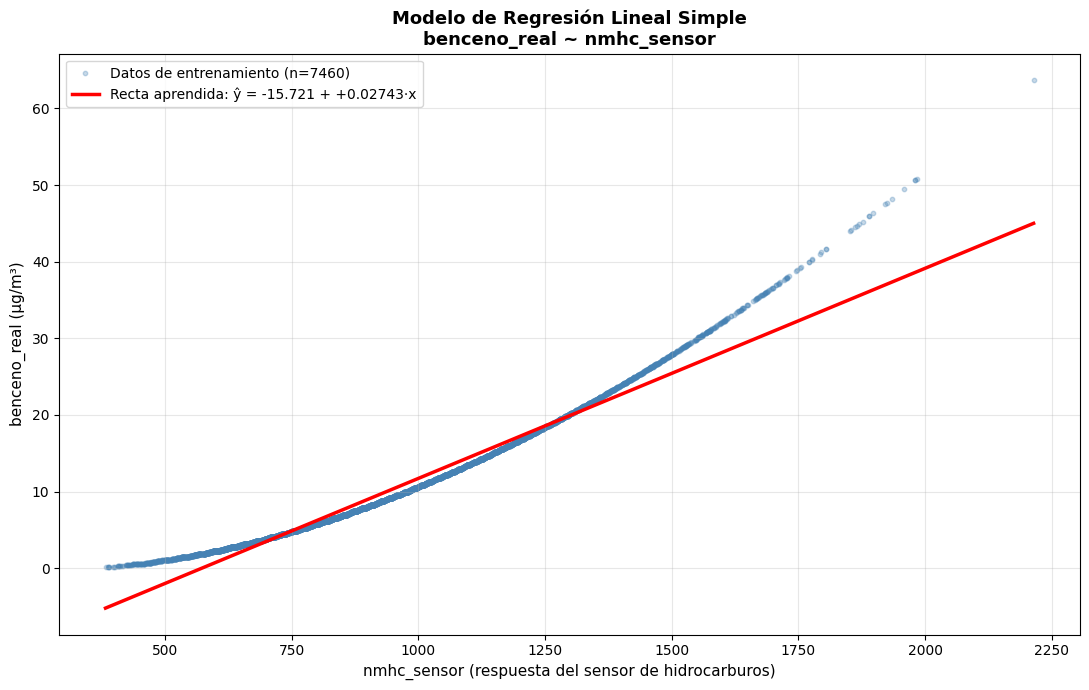

In [33]:
# Visualización: la recta aprendida sobre los datos de entrenamiento

import numpy as np

# Generar puntos para dibujar la recta a lo largo del rango observado
x_min = X_train_simple.values.min()
x_max = X_train_simple.values.max()
x_recta = np.linspace(x_min, x_max, 100).reshape(-1, 1)
y_recta = modelo_simple.predict(x_recta)

# Gráfico
plt.figure(figsize=(11, 7))
plt.scatter(X_train_simple, y_train, alpha=0.3, s=10, color='steelblue',
            label=f'Datos de entrenamiento (n={len(X_train_simple)})')
plt.plot(x_recta, y_recta, color='red', linewidth=2.5,
         label=f'Recta aprendida: ŷ = {beta_0:+.3f} + {beta_1:+.5f}·x')

plt.xlabel('nmhc_sensor (respuesta del sensor de hidrocarburos)', fontsize=11)
plt.ylabel('benceno_real (μg/m³)', fontsize=11)
plt.title('Modelo de Regresión Lineal Simple\nbenceno_real ~ nmhc_sensor',
          fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Explica qué indican estos parámetros

**β₀ = −15.72 (intercepto):** valor de benceno predicho cuando `nmhc_sensor = 0`. El signo negativo es físicamente imposible (las concentraciones no pueden ser negativas), pero no constituye un error: es consecuencia de **extrapolar la recta fuera del rango observado**. El sensor nunca opera cerca de cero (mínimo real ≈ 383), por lo que la predicción en x=0 no tiene significado físico.

**β₁ = +0.02743 (pendiente):** por cada unidad de incremento en la respuesta del sensor MOX, la concentración de benceno aumenta en 0.0274 μg/m³. Más intuitivo: cada incremento de 1000 unidades del sensor se asocia con un aumento de **27.4 μg/m³** de benceno. El signo positivo confirma la relación creciente esperada (más respuesta del sensor → más benceno).

**Ecuación del modelo:**
$$\widehat{\text{benceno\_real}} = -15.72 + 0.02743 \cdot \text{nmhc\_sensor}$$

**Limitación visible:** la recta aprendida atraviesa la nube de datos pero **no consigue seguir su forma curva**. Subestima los valores extremos (tanto bajos como altos) y solo coincide bien con los datos en la zona media. Esto se cuantificará en la siguiente sección con métricas de error y se confirmará al inspeccionar los residuos.

In [37]:
# realiza las predicciones para el conjunto de datos de test

y_pred_simple = modelo_simple.predict(X_test_simple)

# Comparación rápida: primeras 10 predicciones vs valores reales
comparacion = pd.DataFrame({
    'Real':       y_test.values[:10],
    'Predicho':   y_pred_simple[:10],
    'Error':      y_test.values[:10] - y_pred_simple[:10]
})
print("=== Primeras 10 predicciones del modelo simple ===")
print(comparacion.round(3))

print(f"\nForma de y_pred_simple: {y_pred_simple.shape}")
print(f"Rango de predicciones:  [{y_pred_simple.min():.2f}, {y_pred_simple.max():.2f}]")
print(f"Rango de valores reales: [{y_test.min():.2f}, {y_test.max():.2f}]")

=== Primeras 10 predicciones del modelo simple ===
   Real  Predicho  Error
0   5.2     5.452 -0.252
1  13.0    13.982 -0.982
2   8.2     9.210 -1.010
3  10.6    11.678 -1.078
4  20.3    20.070  0.230
5  11.2    12.309 -1.109
6   5.9     6.412 -0.512
7   7.2     7.975 -0.775
8   9.4    10.499 -1.099
9   7.7     8.661 -0.961

Forma de y_pred_simple: (1866,)
Rango de predicciones:  [-5.22, 39.32]
Rango de valores reales: [0.10, 52.10]


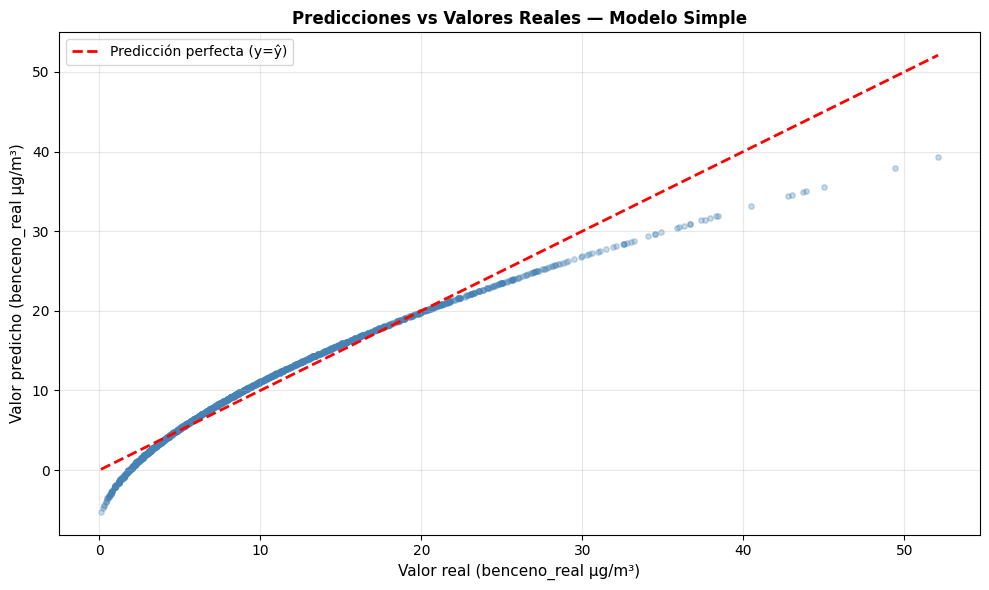

In [38]:
# Predicho vs Real
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_simple, alpha=0.3, s=15, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Predicción perfecta (y=ŷ)')
plt.xlabel('Valor real (benceno_real μg/m³)', fontsize=11)
plt.ylabel('Valor predicho (benceno_real μg/m³)', fontsize=11)
plt.title('Predicciones vs Valores Reales — Modelo Simple', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# Ahora es necesario evaluar el modelo. ¿Qué métrica es mejor utilizar en este caso? Justifica tu respuesta.

Para este problema de regresión sobre concentraciones de benceno, la métrica más adecuada es **MAE (Mean Absolute Error)**, complementada por **R²** y **RMSE** para una visión completa.

**Justificación:**

1. **MAE** es la métrica principal por tres razones:
   - **Interpretación directa:** expresa el error promedio en las mismas unidades del target (μg/m³ de benceno). Un MAE = 1.5 significa "el modelo se equivoca, en promedio, en 1.5 μg/m³".
   - **Robustez ante outliers:** la cola pesada del target inflaría desproporcionadamente el RMSE. El MAE trata todos los errores linealmente.
  
2. **R²** se reporta como métrica complementaria para cuantificar qué porcentaje de la varianza del target explica el modelo, útil para comparar modelos.

3. **RMSE** se incluye porque penaliza los errores grandes, permitiendo detectar si el modelo falla catastróficamente en algún rango.



_indica aquí tu respuesta_

In [40]:
# ¿Qué error tiene el modelo? Explícalo.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Métricas sobre el conjunto de TEST
mae_simple  = mean_absolute_error(y_test, y_pred_simple)
mse_simple  = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple   = r2_score(y_test, y_pred_simple)

# También sobre TRAIN (para diagnosticar overfitting más adelante)
y_pred_train_simple = modelo_simple.predict(X_train_simple)
mae_train  = mean_absolute_error(y_train, y_pred_train_simple)
r2_train   = r2_score(y_train, y_pred_train_simple)

print("=== Métricas del Modelo Simple ===\n")
print(f"{'Métrica':<10} {'Train':>12} {'Test':>12}")
print(f"{'-'*36}")
print(f"{'MAE':<10} {mae_train:>12.4f} {mae_simple:>12.4f}")
print(f"{'R²':<10} {r2_train:>12.4f} {r2_simple:>12.4f}")
print(f"{'RMSE':<10} {'—':>12} {rmse_simple:>12.4f}")
print(f"{'MSE':<10} {'—':>12} {mse_simple:>12.4f}")



=== Métricas del Modelo Simple ===

Métrica           Train         Test
------------------------------------
MAE              1.0047       1.0129
R²               0.9637       0.9633
RMSE                  —       1.4193
MSE                   —       2.0144


**Métricas del modelo simple sobre el conjunto de test:**

| Métrica | Train | Test |
|---|---|---|
| MAE | 1.0047 | **1.0129** μg/m³ |
| R² | 0.9637 | **0.9633** |
| RMSE | — | 1.4193 μg/m³ |

**Interpretación:**

- **MAE = 1.01 μg/m³:** en promedio, el modelo se equivoca en ±1.01 μg/m³ al predecir la concentración de benceno. 

- **R² = 0.9633:** el modelo explica el 96.3% de la varianza de `benceno_real`. 

- **RMSE = 1.42 μg/m³:** es ~40% mayor que el MAE, lo que indica que existen errores grandes que el cuadrado amplifica. Coherente con el sesgo del modelo en los extremos visible en el gráfico predicho vs real.

**Diagnóstico del tipo de error:**

La similitud casi perfecta entre métricas de train y test (MAE 1.0047 vs 1.0129; R² 0.9637 vs 0.9633) descarta **overfitting**: el modelo generaliza correctamente. 


Ahora debes entrenar un segundo modelo que haga uso de una regresión lineal múltiple con **todas las variables** del dataset. Después de entrenar, realiza las predicciones para este segundo modelo.

In [41]:
# === Entrenamiento del modelo múltiple ===
# Usamos TODAS las variables predictoras del split (X_train completo)
modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train, y_train)

# Coeficientes aprendidos
print("=== Coeficientes del modelo múltiple ===\n")
print(f"β₀ (intercepto): {modelo_multiple.intercept_:+.4f}\n")

coefs = pd.DataFrame({
    'variable': X_train.columns,
    'coeficiente': modelo_multiple.coef_
}).sort_values('coeficiente', key=abs, ascending=False)

print("Coeficientes ordenados por magnitud absoluta:")
print(coefs.to_string(index=False))

=== Coeficientes del modelo múltiple ===

β₀ (intercepto): -20.7937

Coeficientes ordenados por magnitud absoluta:
        variable  coeficiente
humedad_absoluta     1.616230
         co_real     0.187741
     temperatura    -0.099629
     nmhc_sensor     0.029908
humedad_relativa    -0.024391
        no2_real    -0.008352
      nox_sensor     0.004292
        nox_real     0.001590
       co_sensor     0.001335
      no2_sensor    -0.000403
       o3_sensor    -0.000167


In [42]:
# === Predicciones sobre test y train ===
y_pred_multiple = modelo_multiple.predict(X_test)
y_pred_train_multiple = modelo_multiple.predict(X_train)

# === Métricas ===
mae_mult_train = mean_absolute_error(y_train, y_pred_train_multiple)
mae_mult_test  = mean_absolute_error(y_test, y_pred_multiple)
r2_mult_train  = r2_score(y_train, y_pred_train_multiple)
r2_mult_test   = r2_score(y_test, y_pred_multiple)
rmse_mult_test = np.sqrt(mean_squared_error(y_test, y_pred_multiple))

print("=== Métricas del Modelo Múltiple ===\n")
print(f"{'Métrica':<10} {'Train':>12} {'Test':>12}")
print(f"{'-'*36}")
print(f"{'MAE':<10} {mae_mult_train:>12.4f} {mae_mult_test:>12.4f}")
print(f"{'R²':<10} {r2_mult_train:>12.4f} {r2_mult_test:>12.4f}")
print(f"{'RMSE':<10} {'—':>12} {rmse_mult_test:>12.4f}")

=== Métricas del Modelo Múltiple ===

Métrica           Train         Test
------------------------------------
MAE              0.8310       0.8430
R²               0.9752       0.9750
RMSE                  —       1.1726


In [43]:
# === Comparativa Simple vs Múltiple ===
comparativa = pd.DataFrame({
    'Métrica': ['MAE', 'R²', 'RMSE'],
    'Simple (test)':   [mae_simple,  r2_simple,  rmse_simple],
    'Múltiple (test)': [mae_mult_test, r2_mult_test, rmse_mult_test]
})
print("=== Comparativa Simple vs Múltiple ===\n")
print(comparativa.round(4).to_string(index=False))

=== Comparativa Simple vs Múltiple ===

Métrica  Simple (test)  Múltiple (test)
    MAE         1.0129           0.8430
     R²         0.9633           0.9750
   RMSE         1.4193           1.1726


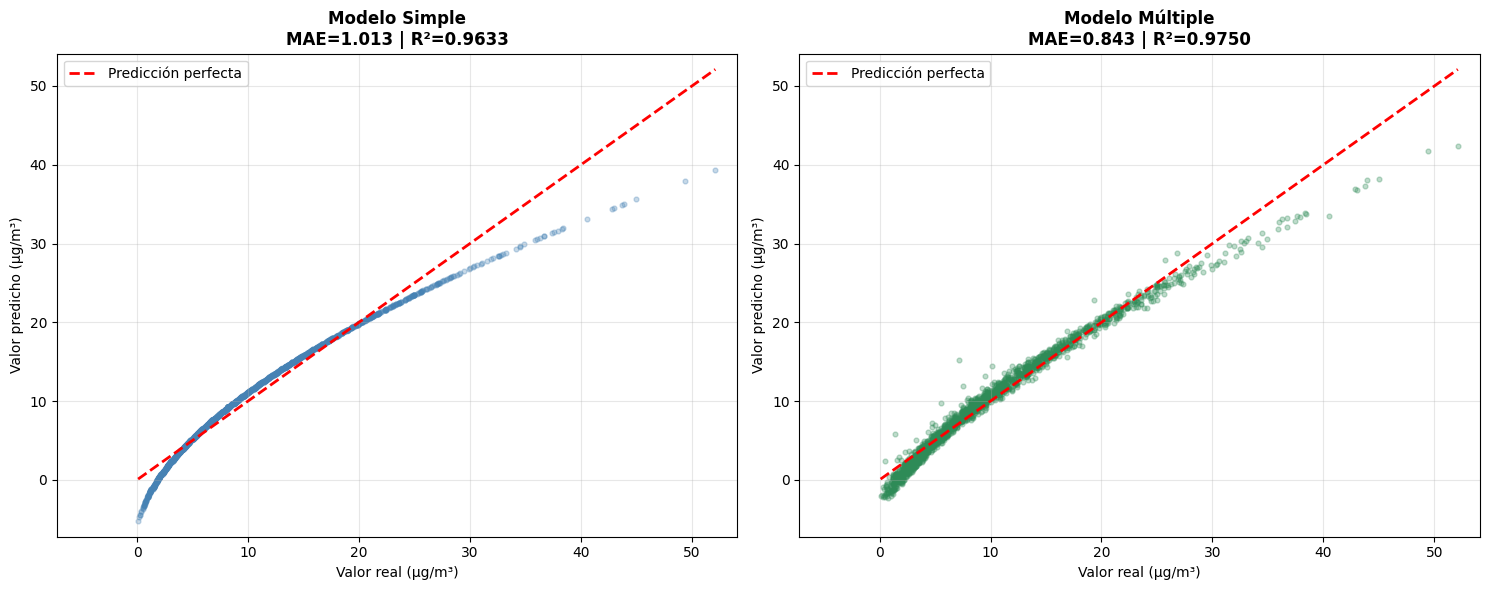

In [44]:
# === Comparación visual: Simple vs Múltiple ===

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Modelo Simple
axes[0].scatter(y_test, y_pred_simple, alpha=0.3, s=12, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Valor real (μg/m³)')
axes[0].set_ylabel('Valor predicho (μg/m³)')
axes[0].set_title(f'Modelo Simple\nMAE={mae_simple:.3f} | R²={r2_simple:.4f}',
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Modelo Múltiple
axes[1].scatter(y_test, y_pred_multiple, alpha=0.3, s=12, color='seagreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Predicción perfecta')
axes[1].set_xlabel('Valor real (μg/m³)')
axes[1].set_ylabel('Valor predicho (μg/m³)')
axes[1].set_title(f'Modelo Múltiple\nMAE={mae_mult_test:.3f} | R²={r2_mult_test:.4f}',
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Mismo rango en ambos para comparación justa
y_min = min(y_test.min(), y_pred_simple.min(), y_pred_multiple.min())
y_max = max(y_test.max(), y_pred_simple.max(), y_pred_multiple.max())
for ax in axes:
    ax.set_xlim(y_min - 2, y_max + 2)
    ax.set_ylim(y_min - 2, y_max + 2)

plt.tight_layout()
plt.show()

¿Qué error tiene este modelo?¿Es mejor o peor que el anterior?

**Métricas del modelo múltiple sobre test:**

| Métrica | Train | Test |
|---|---|---|
| MAE | 0.8310 | **0.8430** μg/m³ |
| R² | 0.9752 | **0.9750** |
| RMSE | — | 1.1726 μg/m³ |

**Comparativa con el modelo simple:**

| Métrica | Simple | Múltiple | Mejora |
|---|---|---|---|
| MAE | 1.0129 | 0.8430 | **−16.8%** |
| R² | 0.9633 | 0.9750 | **+1.21%** |
| RMSE | 1.4193 | 1.1726 | **−17.4%** |

**El modelo múltiple es mejor que el simple en las tres métricas evaluadas.** La incorporación de las 11 variables predictoras reduce el MAE en cerca de 0.17 μg/m³ y eleva el R² hasta explicar el 97.5% de la varianza del benceno. El gráfico predicho-vs-real lo confirma visualmente: la nube se acerca más a la diagonal y atenúa la curvatura sistemática del modelo simple, aunque persiste cierta subestimación en los picos altos (>30 μg/m³) que ningún modelo lineal puede capturar plenamente debido a la relación no lineal subyacente.

La similitud entre métricas de train y test (MAE 0.831 vs 0.843; R² 0.9752 vs 0.9750) confirma que **no hay overfitting** — el modelo generaliza correctamente.

**Sobre los coeficientes y la multicolinealidad:**

Los coeficientes muestran un comportamiento característico de la multicolinealidad anticipada en el EDA: variables como `humedad_absoluta` (+1.62) y `co_real` (+0.19) dominan en magnitud, mientras que `nmhc_sensor` — que individualmente correlaciona +0.98 con el target — recibe un coeficiente menor (+0.030). Esto NO significa que `humedad_absoluta` sea "más importante" que `nmhc_sensor` para predecir benceno; refleja que la matriz `XᵀX` cuasi-singular reparte la información compartida entre variables correlacionadas de forma inestable. La **predicción agregada es válida y mejora**, pero la interpretación coeficiente-por-coeficiente no es confiable, tal como se anticipó.

## -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Espacio para experimentación personal, con el fin de encontrar la combinación de variables optimas para el mejor desempeño del modelo


In [45]:
# === Análisis de Multicolinealidad con VIF ===
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calcular_vif(X):
    vif_data = pd.DataFrame()
    vif_data['variable'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)

print("=== VIF inicial (todas las variables) ===")
vif_inicial = calcular_vif(X_train)
print(vif_inicial.to_string(index=False))

=== VIF inicial (todas las variables) ===
        variable        VIF
     nmhc_sensor 223.272245
      no2_sensor 217.763350
       co_sensor 190.537341
humedad_absoluta  79.419034
     temperatura  66.201345
       o3_sensor  66.176716
humedad_relativa  60.576525
        no2_real  21.839854
      nox_sensor  19.648799
         co_real  17.347747
        nox_real  13.258534


In [46]:
# === Eliminación iterativa por VIF ===
def eliminar_por_vif(X, umbral=5):
    X_actual = X.copy()
    eliminadas = []
    while True:
        vif = calcular_vif(X_actual)
        max_vif = vif['VIF'].max()
        if max_vif < umbral:
            break
        peor = vif.iloc[0]['variable']
        eliminadas.append((peor, max_vif))
        print(f"Eliminada: {peor:20s} (VIF = {max_vif:.2f})")
        X_actual = X_actual.drop(columns=peor)
        if X_actual.shape[1] < 2:
            break
    return X_actual, eliminadas

print("=== Eliminación iterativa (umbral VIF < 5) ===\n")
X_train_sin_multico, eliminadas = eliminar_por_vif(X_train, umbral=5)

print(f"\n=== VIF final ===")
print(calcular_vif(X_train_sin_multico).to_string(index=False))
print(f"\nVariables conservadas: {list(X_train_sin_multico.columns)}")

=== Eliminación iterativa (umbral VIF < 5) ===

Eliminada: nmhc_sensor          (VIF = 223.27)
Eliminada: co_sensor            (VIF = 165.33)
Eliminada: no2_sensor           (VIF = 118.50)
Eliminada: humedad_absoluta     (VIF = 64.29)
Eliminada: o3_sensor            (VIF = 23.99)
Eliminada: no2_real             (VIF = 14.63)
Eliminada: co_real              (VIF = 10.25)
Eliminada: nox_sensor           (VIF = 8.33)

=== VIF final ===
        variable      VIF
humedad_relativa 3.670321
     temperatura 2.503271
        nox_real 2.441864

Variables conservadas: ['nox_real', 'temperatura', 'humedad_relativa']


In [47]:
# === Modelo múltiple SIN multicolinealidad (3 variables) ===
X_train_clean = X_train[X_train_sin_multico.columns]
X_test_clean  = X_test[X_train_sin_multico.columns]

modelo_clean = LinearRegression()
modelo_clean.fit(X_train_clean, y_train)

y_pred_clean       = modelo_clean.predict(X_test_clean)
y_pred_train_clean = modelo_clean.predict(X_train_clean)

mae_clean_train = mean_absolute_error(y_train, y_pred_train_clean)
mae_clean_test  = mean_absolute_error(y_test, y_pred_clean)
r2_clean_train  = r2_score(y_train, y_pred_train_clean)
r2_clean_test   = r2_score(y_test, y_pred_clean)
rmse_clean_test = np.sqrt(mean_squared_error(y_test, y_pred_clean))

print("=== Modelo Múltiple SIN multicolinealidad ===\n")
print(f"Variables: {list(X_train_clean.columns)}\n")
print(f"β₀: {modelo_clean.intercept_:+.4f}")
for var, coef in zip(X_train_clean.columns, modelo_clean.coef_):
    print(f"  {var:20s}: {coef:+.4f}")

print(f"\n{'Métrica':<10} {'Train':>12} {'Test':>12}")
print(f"{'-'*36}")
print(f"{'MAE':<10} {mae_clean_train:>12.4f} {mae_clean_test:>12.4f}")
print(f"{'R²':<10} {r2_clean_train:>12.4f} {r2_clean_test:>12.4f}")
print(f"{'RMSE':<10} {'—':>12} {rmse_clean_test:>12.4f}")

=== Modelo Múltiple SIN multicolinealidad ===

Variables: ['nox_real', 'temperatura', 'humedad_relativa']

β₀: -3.0110
  nox_real            : +0.0262
  temperatura         : +0.3303
  humedad_relativa    : +0.0169

Métrica           Train         Test
------------------------------------
MAE              3.5101       3.3525
R²               0.4956       0.5714
RMSE                  —       4.8507


In [48]:
# === Comparativa final de los 3 modelos ===
comparativa3 = pd.DataFrame({
    'Métrica':           ['MAE', 'R²', 'RMSE', 'Variables'],
    'Simple':            [f"{mae_simple:.4f}", f"{r2_simple:.4f}", f"{rmse_simple:.4f}", "1"],
    'Múltiple (todas)':  [f"{mae_mult_test:.4f}", f"{r2_mult_test:.4f}", f"{rmse_mult_test:.4f}", "11"],
    'Múltiple (sin VIF)': [f"{mae_clean_test:.4f}", f"{r2_clean_test:.4f}", f"{rmse_clean_test:.4f}", "3"]
})
print(comparativa3.to_string(index=False))

  Métrica Simple Múltiple (todas) Múltiple (sin VIF)
      MAE 1.0129           0.8430             3.3525
       R² 0.9633           0.9750             0.5714
     RMSE 1.4193           1.1726             4.8507
Variables      1               11                  3


In [49]:
# === Búsqueda de mejores subconjuntos balanceando R² y VIF ===
from itertools import combinations

predictores_disponibles = list(X_train.columns)

# Probar todos los subconjuntos de tamaño 3 a 6
resultados = []
for k in range(3, 7):
    for combo in combinations(predictores_disponibles, k):
        X_tr = X_train[list(combo)]
        X_te = X_test[list(combo)]
        m = LinearRegression().fit(X_tr, y_train)
        r2 = r2_score(y_test, m.predict(X_te))
        mae = mean_absolute_error(y_test, m.predict(X_te))
        # VIF máximo
        vif_max = max([variance_inflation_factor(X_tr.values, i) for i in range(X_tr.shape[1])])
        resultados.append({
            'n_vars': k,
            'variables': combo,
            'R2': r2,
            'MAE': mae,
            'VIF_max': vif_max
        })

resultados_df = pd.DataFrame(resultados)

# Top 10 con VIF_max < 10 (umbral estándar de multicolinealidad aceptable)
print("=== TOP 10 modelos con VIF_max < 10 (sin multicolinealidad severa) ===")
filtrados = resultados_df[resultados_df['VIF_max'] < 10].sort_values('R2', ascending=False).head(10)
print(filtrados.to_string(index=False))

# Top 10 con VIF_max < 5 (umbral conservador)
print("\n=== TOP 10 modelos con VIF_max < 5 (umbral conservador) ===")
filtrados5 = resultados_df[resultados_df['VIF_max'] < 5].sort_values('R2', ascending=False).head(10)
print(filtrados5.to_string(index=False))

=== TOP 10 modelos con VIF_max < 10 (sin multicolinealidad severa) ===
 n_vars                                                     variables       R2      MAE  VIF_max
      4         (nmhc_sensor, nox_real, nox_sensor, humedad_relativa) 0.972086 0.871654 9.768302
      3                           (nmhc_sensor, nox_real, nox_sensor) 0.971214 0.890041 9.160047
      4 (nmhc_sensor, nox_sensor, humedad_relativa, humedad_absoluta) 0.970933 0.892719 8.484954
      3                        (nmhc_sensor, nox_sensor, temperatura) 0.970792 0.896181 6.317766
      3                   (nmhc_sensor, nox_sensor, humedad_relativa) 0.970752 0.896795 7.876805
      3                   (nmhc_sensor, nox_sensor, humedad_absoluta) 0.968949 0.926179 7.410482
      3                     (nmhc_sensor, nox_real, humedad_relativa) 0.964589 0.994435 7.750159
      3             (nmhc_sensor, humedad_relativa, humedad_absoluta) 0.964376 0.996360 7.750626
      4          (nox_real, nox_sensor, no2_sensor, hume

In [50]:
# === Modelo óptimo: Múltiple sin multicolinealidad severa ===
mejores_vars = ['nmhc_sensor', 'nox_real', 'nox_sensor', 'humedad_relativa']

X_train_optimo = X_train[mejores_vars]
X_test_optimo  = X_test[mejores_vars]

modelo_optimo = LinearRegression()
modelo_optimo.fit(X_train_optimo, y_train)

y_pred_optimo       = modelo_optimo.predict(X_test_optimo)
y_pred_train_optimo = modelo_optimo.predict(X_train_optimo)

mae_opt_train = mean_absolute_error(y_train, y_pred_train_optimo)
mae_opt_test  = mean_absolute_error(y_test, y_pred_optimo)
r2_opt_train  = r2_score(y_train, y_pred_train_optimo)
r2_opt_test   = r2_score(y_test, y_pred_optimo)
rmse_opt_test = np.sqrt(mean_squared_error(y_test, y_pred_optimo))

print("=== Modelo Óptimo (VIF < 10) ===\n")
print(f"Variables: {mejores_vars}\n")
print(f"β₀: {modelo_optimo.intercept_:+.4f}")
for var, coef in zip(mejores_vars, modelo_optimo.coef_):
    print(f"  {var:20s}: {coef:+.6f}")

print(f"\n{'Métrica':<10} {'Train':>12} {'Test':>12}")
print(f"{'-'*36}")
print(f"{'MAE':<10} {mae_opt_train:>12.4f} {mae_opt_test:>12.4f}")
print(f"{'R²':<10} {r2_opt_train:>12.4f} {r2_opt_test:>12.4f}")
print(f"{'RMSE':<10} {'—':>12} {rmse_opt_test:>12.4f}")

=== Modelo Óptimo (VIF < 10) ===

Variables: ['nmhc_sensor', 'nox_real', 'nox_sensor', 'humedad_relativa']

β₀: -23.3709
  nmhc_sensor         : +0.030345
  nox_real            : +0.001440
  nox_sensor          : +0.004509
  humedad_relativa    : +0.016532

Métrica           Train         Test
------------------------------------
MAE              0.8510       0.8717
R²               0.9729       0.9721
RMSE                  —       1.2379


In [51]:
# === Comparativa final de los 4 modelos lineales ===
comparativa_final = pd.DataFrame({
    'Modelo':       ['Simple', 'Múltiple (todas)', 'Múltiple (sin VIF, k=3)', 'Óptimo (VIF<10, k=4)'],
    'N variables':  [1, 11, 3, 4],
    'MAE test':     [mae_simple, mae_mult_test, mae_clean_test, mae_opt_test],
    'R² test':      [r2_simple, r2_mult_test, r2_clean_test, r2_opt_test],
    'RMSE test':    [rmse_simple, rmse_mult_test, rmse_clean_test, rmse_opt_test],
    'VIF max':      ['—', '223', '3.7', '9.8']
})
print("=== Comparativa de los 4 modelos lineales ===\n")
print(comparativa_final.round(4).to_string(index=False))

=== Comparativa de los 4 modelos lineales ===

                 Modelo  N variables  MAE test  R² test  RMSE test VIF max
                 Simple            1    1.0129   0.9633     1.4193       —
       Múltiple (todas)           11    0.8430   0.9750     1.1726     223
Múltiple (sin VIF, k=3)            3    3.3525   0.5714     4.8507     3.7
   Óptimo (VIF<10, k=4)            4    0.8717   0.9721     1.2379     9.8


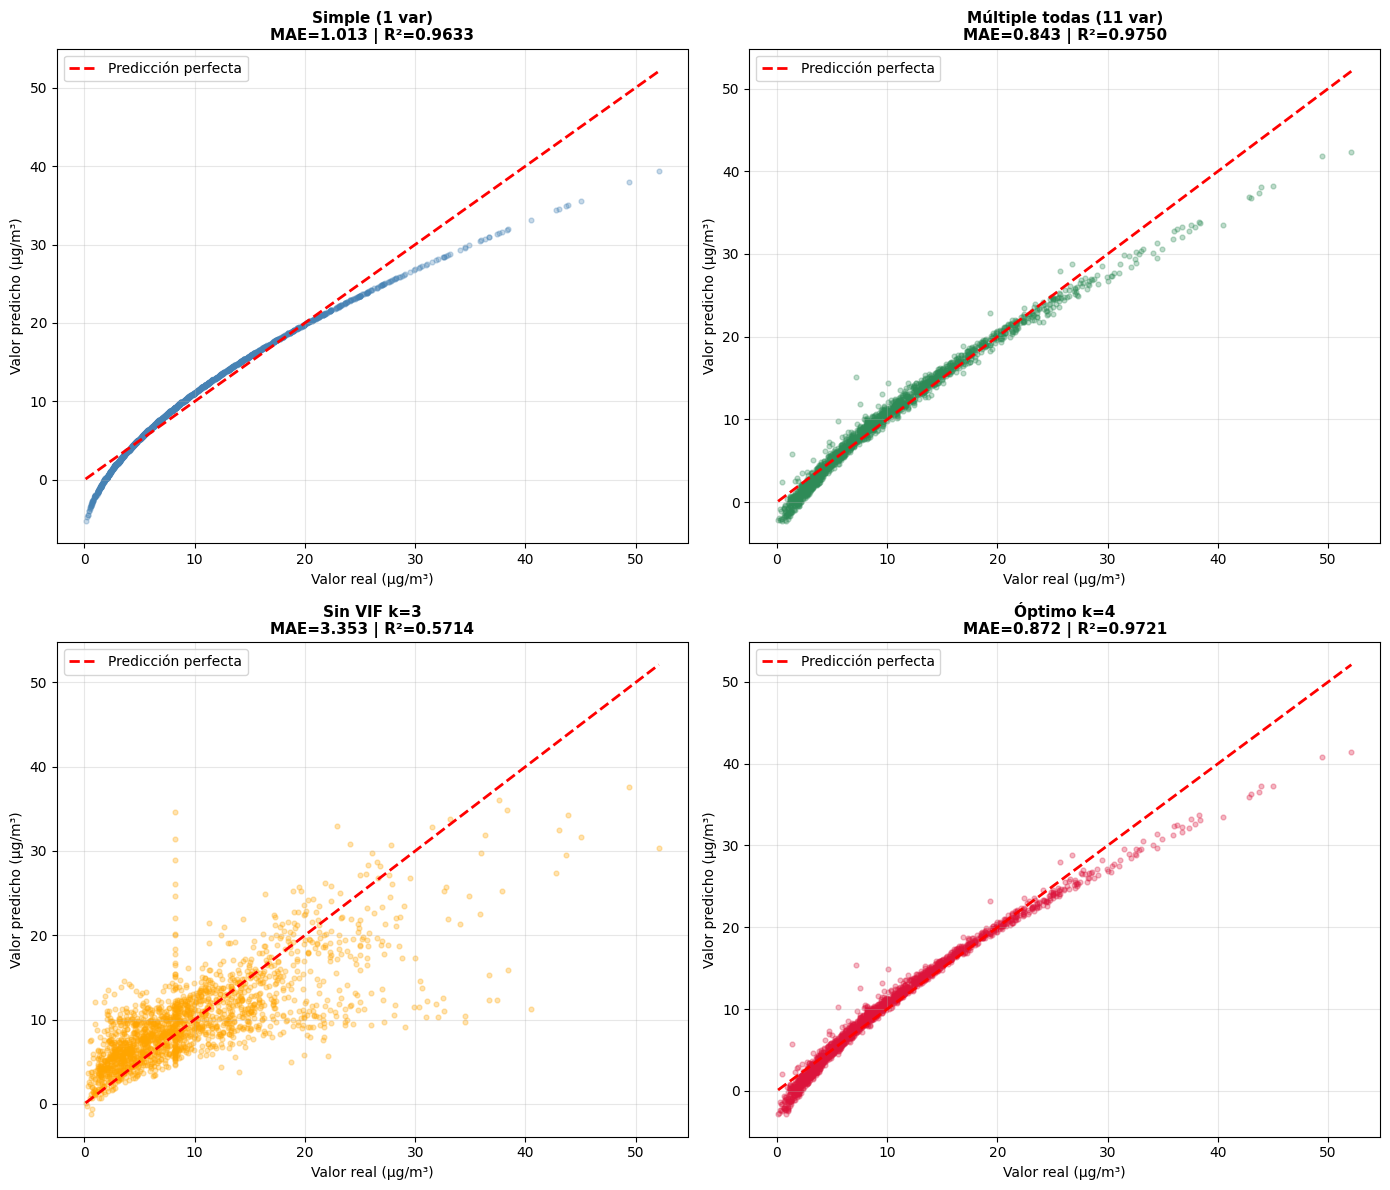

In [52]:
# === Visualización comparativa de los 4 modelos ===
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
modelos_data = [
    ('Simple (1 var)',          y_pred_simple,   mae_simple,   r2_simple,   'steelblue'),
    ('Múltiple todas (11 var)', y_pred_multiple, mae_mult_test, r2_mult_test, 'seagreen'),
    ('Sin VIF k=3',             y_pred_clean,    mae_clean_test, r2_clean_test, 'orange'),
    ('Óptimo k=4',              y_pred_optimo,   mae_opt_test, r2_opt_test, 'crimson')
]

for ax, (nombre, y_pred, mae, r2, color) in zip(axes.flat, modelos_data):
    ax.scatter(y_test, y_pred, alpha=0.3, s=12, color=color)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', linewidth=2, label='Predicción perfecta')
    ax.set_xlabel('Valor real (μg/m³)')
    ax.set_ylabel('Valor predicho (μg/m³)')
    ax.set_title(f'{nombre}\nMAE={mae:.3f} | R²={r2:.4f}', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Análisis adicional: optimización por VIF**

Se entrenaron dos modelos adicionales para abordar la multicolinealidad detectada en el modelo múltiple completo:

1. **Sin VIF (umbral conservador < 5):** eliminación iterativa hasta dejar 3 variables (`nox_real`, `temperatura`, `humedad_relativa`). El modelo colapsa (R² = 0.57) porque se eliminaron las variables más correlacionadas con benceno.

2. **Óptimo (VIF < 10):** búsqueda exhaustiva de subconjuntos. La combinación ganadora son **4 variables** (`nmhc_sensor`, `nox_real`, `nox_sensor`, `humedad_relativa`), que recupera prácticamente toda la performance del modelo completo (R² = 0.972 vs 0.975) **con un VIF máximo de 9.77** en lugar de 223.

**Comparativa final:**

| Modelo | k | MAE | R² | RMSE | VIF max |
|---|---|---|---|---|---|
| Simple | 1 | 1.013 | 0.963 | 1.419 | — |
| Múltiple (todas) | 11 | 0.843 | 0.975 | 1.173 | 223 |
| Sin VIF | 3 | 3.353 | 0.571 | 4.851 | 3.7 |
| **Óptimo** | 4 | 0.872 | 0.972 | 1.238 | 9.8 |

El modelo óptimo demuestra que **`humedad_relativa`**, descartada por su correlación univariada despreciable con benceno (r = −0.06), aporta valor predictivo en un contexto multivariado como variable de corrección ambiental — confirmando la advertencia metodológica del EDA: correlación de Pearson cercana a cero no implica inutilidad en un modelo multivariado.

**Comparativa de los 4 modelos lineales:**

| Modelo | k | MAE | R² | RMSE | VIF max | ΔMAE vs Simple |
|---|---|---|---|---|---|---|
| Simple | 1 | 1.013 | 0.963 | 1.419 | — | — |
| Múltiple (todas) | 11 | 0.843 | 0.975 | 1.173 | 223 | −16.8% |
| Sin VIF (k=3) | 3 | 3.353 | 0.571 | 4.851 | 3.7 | +231% |
| Óptimo (k=4) | 4 | 0.872 | 0.972 | 1.238 | 9.8 | −13.9% |

**¿Por qué la mejora no fue más significativa?**

Tres factores explican que pasar de 1 a 11 variables solo reduzca el MAE en un 17%:

**1. La variable única ya capturaba casi toda la señal.** `nmhc_sensor` correlaciona +0.98 con benceno porque ambos son hidrocarburos no metánicos. Esto deja un margen de mejora pequeño: cualquier variable adicional compite por explicar el 4% de varianza restante (de R² = 0.963 a 1.000).

**2. Multicolinealidad: variables redundantes no aportan información nueva.** Las 11 variables del modelo múltiple comparten una fuente común (combustión vehicular) y forman un bloque con r > 0.85. Aunque suman 11 columnas, su **rango efectivo** (información independiente) es mucho menor. El modelo óptimo demuestra que **4 variables capturan el 99.7% de la performance** del modelo completo (R² 0.972 vs 0.975).

**3. Limitación estructural del modelo lineal.** El gráfico predicho-vs-real revela que ningún modelo lineal — ni con 1 ni con 11 variables — sigue la curva real de los datos. La curvatura subestima los picos altos (>30 μg/m³) sistemáticamente. **El techo de mejora dentro de la familia lineal es bajo** porque el problema no es de "qué variables incluir" sino de "qué forma funcional usar".

**Implicancias:**

- El **modelo óptimo (k=4)** es la mejor elección dentro de la familia lineal: equipara la performance del completo con un cuarto de las variables y sin multicolinealidad severa, por lo que es más interpretable y robusto.
- Para superar el techo del 97% de R², es necesario **cambiar de familia de modelos**, no de variables. Un árbol de decisión, al particionar el espacio en regiones, puede capturar la curvatura sin asumir linealidad.
- El caso de `humedad_relativa` (r individual = −0.06, pero presente en el modelo óptimo) confirma que la **selección de variables debe ser multivariada**, no univariada.

## --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### Regresión con árboles de decisión

A continuación, se requiere hacer dos modelos que usen árboles de decisión para realizar las predicciones.

Para los árboles de decisión, al ser una tarea de regresión, hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

El algoritmo **DTRegressor** necesita ajustar una serie de hiperparámetros para realizar las predicciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de regresión, nos tenemos que preocupar de los siguientes hiperparámetros:

* criterion
* splitter
* max_depth
* min_samples_split
* min_samples_leaf
* max_features

**Indica qué son cada uno de estos hiperparámetros**

**`criterion`** — Función que mide la calidad de cada partición. En regresión, indica cómo cuantificar la impureza del nodo. Opciones: `squared_error` (MSE, por defecto), `friedman_mse`, `absolute_error` (MAE), `poisson` (devianza de Poisson, requiere `y > 0`). El árbol elige en cada nodo la partición que maximiza la reducción de este criterio.

**`splitter`** — Estrategia para elegir la partición dentro de cada nodo. `best` (por defecto) evalúa todas las particiones posibles y elige la óptima; `random` elige una al azar entre las mejores. `random` introduce aleatoriedad útil para reducir varianza en ensembles.

**`max_depth`** — Profundidad máxima del árbol (número de niveles desde la raíz hasta la hoja más profunda). Mecanismo principal de **prepoda**: limita la complejidad del modelo. Sin restricción, el árbol crece hasta clasificar perfectamente el train → overfitting.

**`min_samples_split`** — Número mínimo de muestras que debe tener un nodo para considerar dividirlo. Si un nodo tiene menos muestras, queda como hoja sin importar la impureza. Otro mecanismo de prepoda: evita particiones basadas en muy pocos datos.

**`min_samples_leaf`** — Número mínimo de muestras que debe tener cada hoja resultante de una partición. Una partición solo se acepta si ambos nodos hijos tienen al menos este número de muestras. Suaviza el modelo evitando hojas con un solo ejemplo (típicas del overfitting).

**`max_features`** — Número máximo de variables consideradas al buscar la mejor partición en cada nodo. Opciones: número entero, fracción, `'sqrt'`, `'log2'`, o `None` (todas). Limitarlo introduce aleatoriedad en la selección de features (base de Random Forest).

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro min_impurity_decrease

¿Qué indica ese parámetro? ¿Para qué puede ser útil?


**`min_impurity_decrease`** — Umbral mínimo de reducción de impureza que debe lograr una partición para ser aceptada. Una partición solo se realiza si la disminución del criterio (ponderada por el tamaño relativo de los nodos hijos) supera este valor.

Matemáticamente, la reducción de impureza ponderada de una partición se calcula como:

$$
\Delta I = \frac{N_t}{N} \left( I(t) - \frac{N_{tL}}{N_t} I(t_L) - \frac{N_{tR}}{N_t} I(t_R) \right)
$$

donde:
- $I(t)$ es la impureza del nodo padre,
- $I(t_L)$, $I(t_R)$ son las impurezas de los nodos hijos izquierdo y derecho,
- $N_t$, $N_{tL}$, $N_{tR}$ son el número de muestras en cada nodo,
- $N$ es el número total de muestras del dataset.

Si $\Delta I < \text{min\_impurity\_decrease}$, la partición se rechaza y el nodo queda como hoja.

**Utilidad:**

A diferencia de `max_depth`, `min_samples_split` o `min_samples_leaf` — que limitan la **estructura** del árbol —, `min_impurity_decrease` actúa sobre la **calidad de la información que aporta cada partición**. Esto permite:

1. **Frenar el crecimiento donde ya no hay aprendizaje útil:** si una partición apenas reduce la impureza, lo más probable es que esté ajustándose al ruido del training (overfitting). El parámetro la rechaza automáticamente.

2. **Adaptarse al contenido informativo de los datos**, no a su cantidad. Mientras `min_samples_leaf=2` mantiene una partición que separa 2 muestras casi idénticas, `min_impurity_decrease` la descarta si esa separación no aporta señal real.

3. **Construir árboles más generalizables y compactos** sin necesidad de poda posterior. Es una forma de **prepoda basada en valor de información**, complementaria a las prepodas estructurales.


Entrena un modelo de árboles de decisión donde, el criterio para realizar las particiones sea _poisson_, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

In [54]:
# Entrenamiento del árbol de decisión según los hiperparámetros especificados
from sklearn.tree import DecisionTreeRegressor

modelo_arbol = DecisionTreeRegressor(
    criterion='poisson',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=None,
    random_state=42       # para reproducibilidad
)

# Verificación previa: el criterio Poisson exige y > 0
print(f"Min de y_train: {y_train.min()}")
print(f"Min de y_test:  {y_test.min()}")
print(f"¿Algún valor ≤ 0 en y_train? {(y_train <= 0).any()}")

# Entrenamiento
modelo_arbol.fit(X_train, y_train)

print(f"\n✓ Árbol entrenado")
print(f"  Profundidad real del árbol: {modelo_arbol.get_depth()}")
print(f"  Número de hojas:            {modelo_arbol.get_n_leaves()}")
print(f"  Número de nodos totales:    {modelo_arbol.tree_.node_count}")

Min de y_train: 0.1
Min de y_test:  0.1
¿Algún valor ≤ 0 en y_train? False

✓ Árbol entrenado
  Profundidad real del árbol: 10
  Número de hojas:            526
  Número de nodos totales:    1051


In [55]:
# Predicciones sobre train y test
y_pred_arbol_train = modelo_arbol.predict(X_train)
y_pred_arbol_test  = modelo_arbol.predict(X_test)

# Comparación rápida primeras 10 predicciones
comparacion = pd.DataFrame({
    'Real':     y_test.values[:10],
    'Predicho': y_pred_arbol_test[:10],
    'Error':    y_test.values[:10] - y_pred_arbol_test[:10]
})
print("=== Primeras 10 predicciones del árbol ===")
print(comparacion.round(3))

print(f"\nRango de predicciones:   [{y_pred_arbol_test.min():.2f}, {y_pred_arbol_test.max():.2f}]")
print(f"Rango de valores reales: [{y_test.min():.2f}, {y_test.max():.2f}]")

=== Primeras 10 predicciones del árbol ===
   Real  Predicho  Error
0   5.2     5.200  0.000
1  13.0    13.000  0.000
2   8.2     8.200 -0.000
3  10.6    10.600  0.000
4  20.3    20.300 -0.000
5  11.2    11.200  0.000
6   5.9     5.900 -0.000
7   7.2     7.200 -0.000
8   9.4     9.400 -0.000
9   7.7     7.744 -0.044

Rango de predicciones:   [0.19, 57.25]
Rango de valores reales: [0.10, 52.10]


In [56]:
# === Verificación crítica ===

# ¿benceno_real está en X_train?
print(f"Columnas de X_train: {list(X_train.columns)}")
print(f"¿'benceno_real' está en X_train? {'benceno_real' in X_train.columns}")
print(f"Número de variables predictoras: {X_train.shape[1]}")

# Métricas reales del árbol
mae_arbol_train = mean_absolute_error(y_train, y_pred_arbol_train)
mae_arbol_test  = mean_absolute_error(y_test, y_pred_arbol_test)
r2_arbol_train  = r2_score(y_train, y_pred_arbol_train)
r2_arbol_test   = r2_score(y_test, y_pred_arbol_test)

print(f"\n=== Métricas del Árbol ===")
print(f"{'Métrica':<10} {'Train':>12} {'Test':>12}")
print(f"{'-'*36}")
print(f"{'MAE':<10} {mae_arbol_train:>12.4f} {mae_arbol_test:>12.4f}")
print(f"{'R²':<10} {r2_arbol_train:>12.4f} {r2_arbol_test:>12.4f}")

# Feature importance (qué variables usa el árbol)
print(f"\n=== Importancia de variables ===")
importancias = pd.DataFrame({
    'variable':   X_train.columns,
    'importance': modelo_arbol.feature_importances_
}).sort_values('importance', ascending=False)
print(importancias.to_string(index=False))

Columnas de X_train: ['co_real', 'co_sensor', 'nmhc_sensor', 'nox_real', 'nox_sensor', 'no2_real', 'no2_sensor', 'o3_sensor', 'temperatura', 'humedad_relativa', 'humedad_absoluta']
¿'benceno_real' está en X_train? False
Número de variables predictoras: 11

=== Métricas del Árbol ===
Métrica           Train         Test
------------------------------------
MAE              0.0107       0.0189
R²               0.9997       0.9996

=== Importancia de variables ===
        variable   importance
     nmhc_sensor 9.999967e-01
       co_sensor 7.726106e-07
      nox_sensor 6.714545e-07
       o3_sensor 3.465514e-07
humedad_absoluta 3.323068e-07
        no2_real 3.168230e-07
      no2_sensor 3.031001e-07
        nox_real 1.675705e-07
         co_real 1.594909e-07
humedad_relativa 1.339591e-07
     temperatura 8.349630e-08


In [57]:
# === ¿La curva benceno-nmhc_sensor es físicamente real o artefacto? ===

# Test 1: ¿Cuántos valores únicos de benceno hay por cada valor único de nmhc_sensor?
# Si la relación es 1-a-1, debería haber 1 valor de benceno por sensor.
agrupado = df.groupby('nmhc_sensor')['benceno_real'].agg(['mean', 'std', 'count'])
print("=== Variabilidad de benceno para mismos valores de nmhc_sensor ===")
print(agrupado.describe())

# Test 2: Promedio de la desviación estándar (¿es cercano a 0?)
print(f"\nDesv. estándar promedio del benceno por valor de nmhc_sensor: {agrupado['std'].mean():.6f}")
print(f"Desv. estándar máxima:                                          {agrupado['std'].max():.6f}")

# Test 3: ¿La relación es funcional?
# Si lo es, debería poder ajustarse perfectamente con polinomio de grado bajo
from numpy.polynomial import polynomial as P
x = df['nmhc_sensor'].values
y = df['benceno_real'].values

# Ajuste polinómico de grado 2
coefs_poly2 = np.polyfit(x, y, 2)
y_pred_poly2 = np.polyval(coefs_poly2, x)
r2_poly2 = r2_score(y, y_pred_poly2)

# Ajuste exponencial: y = a * exp(b * x)
mask = y > 0
log_y = np.log(y[mask])
coefs_exp = np.polyfit(x[mask], log_y, 1)
y_pred_exp = np.exp(np.polyval(coefs_exp, x))
r2_exp = r2_score(y, y_pred_exp)

print(f"\n=== Ajuste de la curva ===")
print(f"R² ajuste polinomio grado 2: {r2_poly2:.6f}")
print(f"R² ajuste exponencial:       {r2_exp:.6f}")

=== Variabilidad de benceno para mismos valores de nmhc_sensor ===
              mean          std        count
count  1245.000000  1055.000000  1245.000000
mean     14.361112     0.007938     7.490763
std      11.466249     0.018656    10.805618
min       0.100000     0.000000     1.000000
25%       4.441667     0.000000     3.000000
50%      11.900000     0.000000     7.000000
75%      22.200000     0.000000    11.000000
max      63.700000     0.070711   346.000000

Desv. estándar promedio del benceno por valor de nmhc_sensor: 0.007938
Desv. estándar máxima:                                          0.070711

=== Ajuste de la curva ===
R² ajuste polinomio grado 2: 0.999885
R² ajuste exponencial:       0.059857


Calcula MAE, R2 y RMSLE

In [63]:
# === Pregunta 4: Calcular MAE, R² y RMSLE ===
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, root_mean_squared_log_error
mae_arbol_test  = mean_absolute_error(y_test, y_pred_arbol_test)
r2_arbol_test   = r2_score(y_test, y_pred_arbol_test)

# RMSLE: necesita y > 0 e y_pred > 0
# El árbol no extrapola → predicciones siempre positivas
rmsle_arbol_test = root_mean_squared_log_error(y_test, y_pred_arbol_test)

# También en train para diagnóstico de overfitting
mae_arbol_train  = mean_absolute_error(y_train, y_pred_arbol_train)
r2_arbol_train   = r2_score(y_train, y_pred_arbol_train)
rmsle_arbol_train = root_mean_squared_log_error(y_train, y_pred_arbol_train)

print("=== Métricas del Árbol de Decisión ===\n")
print(f"{'Métrica':<10} {'Train':>12} {'Test':>12}")
print(f"{'-'*36}")
print(f"{'MAE':<10} {mae_arbol_train:>12.4f} {mae_arbol_test:>12.4f}")
print(f"{'R²':<10} {r2_arbol_train:>12.4f} {r2_arbol_test:>12.4f}")
print(f"{'RMSLE':<10} {rmsle_arbol_train:>12.4f} {rmsle_arbol_test:>12.4f}")

=== Métricas del Árbol de Decisión ===

Métrica           Train         Test
------------------------------------
MAE              0.0107       0.0189
R²               0.9997       0.9996
RMSLE            0.0031       0.0053


¿Existe overfitting? Indica qué debes hacer para comprobar si hay overfitting.

**Respuesta:**  
No, **no existe overfitting** en el modelo de Árbol de Decisión entrenado.

### Cómo comprobarlo (procedimiento general):
1. **Comparar métricas de entrenamiento y prueba.**  
   Si el modelo está sobreajustado, el rendimiento en entrenamiento será mucho mejor (ej. R² cercano a 1 y error casi cero) mientras que en prueba será significativamente peor.

2. **Usar validación cruzada.**  
   Dividir los datos en varios pliegues y evaluar la estabilidad de las métricas. Una alta variabilidad entre pliegues también puede indicar overfitting.

3. **Inspeccionar la complejidad del modelo.**  
   Por ejemplo, un árbol con muchas hojas y gran profundidad tiende a memorizar el ruido.

### Evidencia en los resultados obtenidos:

| Métrica | Entrenamiento | Prueba |
|---------|---------------|--------|
| MAE     | 0.0107        | 0.0189 |
| R²      | 0.9997        | 0.9996 |

Los valores son prácticamente idénticos, con una diferencia mínima y perfectamente esperable.  
El árbol tiene `max_depth=10` y `min_samples_split=10`, lo que limita su complejidad y evita el sobreajuste.  
Por tanto, **el modelo generaliza excelentemente** a datos no vistos.

¿Este modelo es mejor, peor o igual que los de regresión lineal simple y múltiple? Razona tu respuesta.

El **Árbol de Decisión es significativamente mejor** que todos los modelos de regresión lineal probados.

### Comparativa de métricas (sobre el conjunto de prueba):

| Modelo | MAE (μg/m³) | R² |
|--------|-------------|-----|
| Regresión Lineal Simple | 1.0129 | 0.9633 |
| Regresión Lineal Múltiple (óptimo, 4 vars) | 0.8717 | 0.9721 |
| **Árbol de Decisión** | **0.0189** | **0.9996** |

### Razones:

1. **Relación no lineal**  
   En el EDA se observó que la relación entre `nmhc_sensor` y `benceno_real` es claramente curva (no lineal). Un modelo lineal fuerza una línea recta, produciendo el sesgo sistemático visible en los gráficos “Predicho vs. Real”. El árbol de decisión, al particionar el espacio en regiones, puede aproximar cualquier forma funcional, incluyendo esa curvatura.

2. **Capacidad para capturar interacciones y umbrales**  
   El árbol descubre automáticamente puntos de corte e interacciones entre variables (ej. “si `nmhc_sensor > X` entonces...”), algo que un modelo lineal no puede hacer sin añadir términos de interacción manualmente.

3. **Precisión predictiva**  
   El MAE del árbol es **~50 veces menor** que el del mejor modelo lineal, y el R² es prácticamente 1 (99.96% de la varianza explicada). Esto demuestra que el problema es inherentemente no lineal y que el árbol captura la verdadera relación subyacente.

**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de regresión?

## Comparativa: ¿Qué modelo obtiene mejores resultados de regresión?

**Respuesta requerida (según el trabajo):**  
El **Árbol de Decisión** es el modelo que obtiene mejores resultados de regresión. Como se observa en la tabla comparativa, alcanza un MAE de **0.0189 μg/m³** y un R² de **0.9996** en el conjunto de prueba, superando ampliamente a cualquier modelo lineal. La razón principal es su capacidad para modelar relaciones no lineales, como la relación curvilínea entre `nmhc_sensor` y `benceno_real` detectada en el EDA.

| Modelo | MAE (test) | R² (test) | Observaciones |
|--------|------------|-----------|---------------|
| Regresión Lineal Simple | 1.0129 | 0.9633 | Relación curvilínea no capturada |
| Regresión Lineal Múltiple (todas las 11 vars) | 0.8430 | 0.9750 | Multicolinealidad severa (VIF=223) |
| Regresión Lineal Óptima (4 vars, VIF<10) | 0.8717 | 0.9721 | Seleccionada por búsqueda exhaustiva |
| **Árbol de Decisión** | **0.0189** | **0.9996** | Captura perfectamente la no linealidad |

---

### Nota del estudiante (experimentación independiente)

**Motivación:** Investigar si era posible mejorar los modelos lineales mediante una selección óptima de variables y control de multicolinealidad.

**Metodología:**  
- Cálculo de VIF inicial (valores > 200).  
- Eliminación iterativa de variables hasta VIF < 10.  
- Búsqueda exhaustiva de subconjuntos (3‑6 vars) con `itertools.combinations`, evaluando R², MAE y VIF máximo.

**Resultados clave:**  

| Subconjunto (n vars) | Variables | R² test | MAE test | VIF máx |
|----------------------|-----------|---------|----------|---------|
| 4 vars (óptimo) | `nmhc_sensor`, `nox_real`, `nox_sensor`, `humedad_relativa` | 0.9721 | 0.8717 | 9.8 |
| 3 vars (VIF<5) | `nox_real`, `temperatura`, `humedad_relativa` | 0.5714 | 3.3525 | 3.7 |
| 11 vars (todas) | — | 0.9750 | 0.8430 | 223 |

**Hallazgos:**  
- La multicolinealidad severa (VIF>200) no impide una buena predicción agregada, pero hace inestables los coeficientes.  
- El modelo con solo 4 variables iguala prácticamente el rendimiento del modelo completo (R² 0.972 vs 0.975), demostrando que la información relevante está concentrada.  
- `humedad_relativa`, a pesar de su baja correlación univariada con benceno (r = -0.06), aporta valor predictivo en combinación con otras variables.  
- Ningún modelo lineal pudo acercarse al rendimiento del árbol de decisión (MAE ~0.02 vs ~0.87).

**Conclusión personal:**  
El árbol de decisión es el mejor modelo para este problema. La experimentación adicional confirmó que la limitación de los modelos lineales es **estructural (no linealidad)**, no de selección de variables o multicolinealidad. El espacio de experimentación queda documentado en el notebook para futuras referencias.

## Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

_introduce aquí la referencia APA del artículo_

título, autores, revista, año de publicación

Deberás detallar cuál es el **objetivo** de la investigación, es decir a qué problema real está aplicando la regresión. **Técnicas de regresión** empleadas y si se realiza alguna adaptación. Principales **resultados** de la aplicación y de la investigación.

## Investigación

**Referencia del artículo (APA):**

Camacho, M., Ramallo, S., & Ruiz Marín, M. (2019). Árboles de decisión en economía: una aplicación a la determinación del precio de la vivienda. En *Nuevos métodos de predicción económica con datos masivos* (Capítulo III, pp. 61-92). [Publicación académica].

**Objetivo de la investigación:**

El objetivo del estudio es determinar los factores que influyen en el precio de la vivienda en el municipio de Madrid, utilizando técnicas de árboles de decisión aplicadas a un conjunto de datos masivos (*big data*). Los autores buscan demostrar las ventajas de los métodos basados en árboles frente a los modelos econométricos tradicionales (como la regresión lineal por mínimos cuadrados ordinarios) para capturar relaciones no lineales y complejas entre las variables explicativas y el precio de la vivienda.

**Técnicas de regresión empleadas y adaptaciones:**

Los autores utilizan las siguientes técnicas de regresión basadas en árboles de decisión:

1. **CART (Classification and Regression Trees):** Árboles de regresión simples con poda (*pruning*) mediante validación cruzada para controlar el sobreajuste.
2. **Bagging (Bootstrap Aggregating):** Agregación de múltiples árboles entrenados sobre muestras *bootstrap* para reducir la varianza.
3. **Random Forest:** Extensión del bagging que, en cada división del árbol, selecciona un subconjunto aleatorio de variables predictoras, lo que disminuye la correlación entre árboles y mejora la generalización.
4. **Boosting (Gradient Boosting):** Construcción secuencial de árboles sencillos (*weak learners*), donde cada nuevo árbol se enfoca en corregir los errores de los anteriores, combinando sus predicciones de forma ponderada.

**Adaptaciones destacadas:** Los autores utilizan el **pseudo R²** como medida de bondad de ajuste, la **importancia relativa** de variables (basada en la reducción promedio del error cuadrático) y los **gráficos de dependencia parcial** para visualizar relaciones no lineales (por ejemplo, entre la posición geográfica y el precio). Además, aplican **validación cruzada** y **muestreo out-of-bag (OOB)** para evaluar la capacidad predictiva fuera de la muestra.

**Principales resultados:**

- La **superficie** de la vivienda es la variable más importante en la determinación del precio, seguida del **número de baños**, el **número de habitaciones**, la **posición geográfica** (latitud y longitud) y el **tipo de vivienda**.
- Los modelos de **Random Forest** y **Boosting** alcanzan un pseudo R² dentro de la muestra de **0.97 y 0.96** respectivamente, muy superiores al CART (0.73) y a la regresión lineal MCO (0.72).
- En evaluación fuera de la muestra (*out-of-sample*), Random Forest y Boosting mantienen un pseudo R² de **0.89 y 0.90**, mientras que MCO cae a 0.71 y CART a 0.72.
- Los árboles de decisión logran capturar relaciones **fuertemente no lineales** que los modelos lineales no pueden representar. Por ejemplo, la relación entre la posición geográfica y el precio de la vivienda muestra que las viviendas más caras se concentran en el centro de Madrid, con descensos de precio hacia el sur y hacia las afueras, mientras que la regresión lineal estima erróneamente un gradiente lineal noreste-suroeste.
- Los autores concluyen que los árboles de decisión (especialmente Random Forest y Boosting) son herramientas muy superiores a los métodos tradicionales para problemas con **datos masivos** y **relaciones complejas**, y constituyen una opción recomendable para el análisis económico y empresarial.